> **Not:** Bu, GitHub için hazırlanmış kopyadır. Veri seti lisansı gereği dataset görüntüleri çıkarıldı; kod, tablolar, sayılar ve grafikler aynıdır.

# WashMom Vision

**Kıyafet fotoğrafından kumaş ve renk çıkarıp yıkama grubu öneren görüntü işleme projesi**

```
📷 Fotoğraf ─┬─► 🧠 EfficientNetV2B0 ─► kumaş (denim, cotton, ...)  ─┐
             └─► 🎨 OpenCV          ─► renk (white/light/dark/colored) ─┴─► 📋 Kural motoru ─► yıkama grubu
```

**Dataset:** DeepFashion-MultiModal — https://github.com/yumingj/DeepFashion-MultiModal
(Jiang et al., *Text2Human*, SIGGRAPH 2022 · yalnızca ticari olmayan araştırma amaçlı)

**İçindekiler**
1. Kurulum
2. Veri erişimi
3. Etiket dosyası
4. Kumaş sınıf dağılımı
5. Parsing maskeleri
6. İlk görüntü ve maske
7. İlk garment crop testi
8. Etiketlerin elle kontrolü
9. Maske ↔ etiket uyumu
10. Crop kuralı ve görsel test
11. Tüm crop'ları üretme + manifest
12. EDA görselleştirmeleri
13. Filtre, nihai sınıflar, train/val/test split
14. Custom CNN baseline
15. EfficientNetV2B0 transfer learning + fine-tuning (+ class weight iyileştirmesi, karar ayarı)
16. Test seti: model karşılaştırması, confusion matrix
17. Hata analizi (shortcut, confidence, hata galerisi)
18. Renk analizi (OpenCV)
19. Kural motoru ve uçtan uca demo
20. Sonuç
21. Kendi fotoğrafınla dene (inference)

## 1. Kurulum

Kod VS Code'un Colab eklentisiyle Colab GPU'sunda çalışıyor; veri Google Drive'da. Colab'ın kendi diski geçici olduğu için kalıcı her şey Drive'daki `WashMom_Vision/` klasöründe:

```
WashMom_Vision/
├── data_raw/            orijinal dataset (labels.zip, segm.zip, images.zip) — dokunulmaz
├── processed/           mask_stats.csv, crop'lar, manifest
├── models/              eğitilmiş modeller
└── outputs/figures/     rapor grafikleri
```

Bu notebook **baştan sona tekrar çalıştırılabilir**: ağır adımlar (indirme, maske istatistikleri) daha önce yapıldıysa atlanır.

In [44]:
from google.colab import drive
drive.mount("/content/drive")

import os, io, re, shutil, zipfile                     # dosya/zip işlemleri, metin deseni (re)
import numpy as np                                     # sayı dizileri (görüntü = sayı dizisi)
import pandas as pd                                    # tablolar
import cv2                                             # OpenCV: görüntü okuma ve işleme
import matplotlib.pyplot as plt                        # grafik ve görüntü çizme
from PIL import Image                                  # maskeyi sınıf numaralarıyla okumak için
from tqdm.auto import tqdm                             # uzun döngülerde ilerleme çubuğu
import tensorflow as tf

print("TensorFlow:", tf.__version__, "| GPU:", tf.config.list_physical_devices("GPU"))

PROJECT_DIR = "/content/drive/MyDrive/WashMom_Vision"
RAW_DIR  = os.path.join(PROJECT_DIR, "data_raw")       # orijinal dataset
PROC_DIR = os.path.join(PROJECT_DIR, "processed")      # bizim ürettiğimiz veriler
FIG_DIR  = os.path.join(PROJECT_DIR, "outputs", "figures")
for sub in ["data_raw", "processed", "models", "outputs/figures", "outputs/error_gallery"]:
    os.makedirs(os.path.join(PROJECT_DIR, sub), exist_ok=True)   # varsa dokunmaz

# Etiket kodları (resmi dokümantasyon): listedeki sıra = kod numarası
FABRIC_NAMES = ["denim", "cotton", "leather", "furry", "knitted", "chiffon", "other", "NA"]
FABRIC_MAP = dict(enumerate(FABRIC_NAMES))             # {0: "denim", 1: "cotton", ...}
NA = 7                                                 # "görünmüyor" kodu

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow: 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Veri erişimi

Dataset resmi repodaki Google Drive linklerinden **parça parça** indirildi; sadece gerekli üç parça kullanılıyor:

| Dosya | İçerik | Nasıl indirildi |
|---|---|---|
| `labels.zip` | kumaş / desen / şekil etiketleri | tarayıcıdan |
| `segm.zip` | 12.701 parsing maskesi | tarayıcıdan |
| `images.zip` | 44.096 görüntü (6,82 GB) | Colab'dan `gdown` ile (~1,5 dk) |

`images.zip` tarayıcıdan yüklenemeyecek kadar büyüktü. Google Drive linkleri büyük dosyalarda "virüs taraması yapılamadı" onay sayfası gösterdiği için `wget` yerine bu onayı otomatik geçen `gdown` kullanıldı. Colab'da Drive'a yazılan büyük dosyalar önce önbelleğe gider; `drive.flush_and_unmount()` buluta yüklenmesini bekler.

Görüntüler Drive'dan tek tek okunursa çok yavaş olur; bu yüzden `images.zip` her oturumda bir kez Colab'ın **yerel diskine** kopyalanıyor.

In [2]:
import gdown

IMAGES_FILE_ID = "1U2PljA7NE57jcSSzPs21ZurdIPXdYZtN"              # resmi Images linkinin ID'si
IMAGES_ZIP = os.path.join(RAW_DIR, "images.zip")
SEGM_ZIP   = os.path.join(RAW_DIR, "segm.zip")
LABELS_ZIP = os.path.join(RAW_DIR, "labels.zip")

if not os.path.exists(IMAGES_ZIP):                                # sadece yoksa indir
    gdown.download(id=IMAGES_FILE_ID, output=IMAGES_ZIP, quiet=False)
    drive.flush_and_unmount()                                     # buluta yüklenmesini bekle
    drive.mount("/content/drive")

for name in sorted(os.listdir(RAW_DIR)):
    print(f"{name:12s} -> {os.path.getsize(os.path.join(RAW_DIR, name)) / 1024**2:8.1f} MB")

LOCAL_IMAGES_ZIP = "/content/images.zip"                          # Colab'ın hızlı yerel diski
if not os.path.exists(LOCAL_IMAGES_ZIP):                          # oturum başına bir kez (~1-3 dk)
    print("images.zip yerel diske kopyalanıyor...")
    shutil.copy(IMAGES_ZIP, LOCAL_IMAGES_ZIP)

img_zip = zipfile.ZipFile(LOCAL_IMAGES_ZIP)                       # zip'leri açık tutuyoruz,
seg_zip = zipfile.ZipFile(SEGM_ZIP)                               # içlerinden dosya okuyacağız
img_paths = {os.path.basename(n): n for n in img_zip.namelist() if n.endswith(".jpg")}
print("\nZip'teki görüntü sayısı:", len(img_paths))

images.zip   ->   6506.1 MB
labels       ->      0.0 MB
labels.zip   ->      0.6 MB
segm.zip     ->     90.5 MB
images.zip yerel diske kopyalanıyor...

Zip'teki görüntü sayısı: 44096


## 3. Etiket dosyası

`labels.zip` içinden bize lazım olan `texture/fabric_ann.txt`. Önce ham formatına bakıyoruz, sonra tablo olarak yüklüyoruz.

In [3]:
with zipfile.ZipFile(LABELS_ZIP) as z:
    for info in z.infolist():
        print(f"{info.filename:45s} {info.file_size / 1024**2:6.2f} MB")
    z.extractall(RAW_DIR)                              # data_raw/labels/... olarak açılır

FABRIC_PATH = os.path.join(RAW_DIR, "labels", "texture", "fabric_ann.txt")
print("\nfabric_ann.txt ilk 5 satır (ham):")
with open(FABRIC_PATH) as f:
    for i in range(5):
        print(repr(f.readline()))                      # repr: gizli karakterleri (\n, \t) gösterir

labels/                                         0.00 MB
labels/shape/                                   0.00 MB
labels/shape/shape_anno_all.txt                 2.78 MB
labels/texture/                                 0.00 MB
labels/texture/fabric_ann.txt                   2.13 MB
labels/texture/pattern_ann.txt                  2.13 MB

fabric_ann.txt ilk 5 satır (ham):
'<veri-seti-dosyası> 1 1 7\n'
'<veri-seti-dosyası> 1 1 7\n'
'<veri-seti-dosyası> 1 1 7\n'
'<veri-seti-dosyası> 1 1 7\n'
'<veri-seti-dosyası> 0 1 7\n'


**Bulgu:** Format `<görüntü_adı> <upper> <lower> <outer>`, tek boşlukla ayrılmış, başlık satırı yok.

- `texture/fabric_ann.txt` → kumaş etiketleri (**ana dosyamız**)
- `texture/pattern_ann.txt` → desen (floral, striped...). Gerçek RGB renk değil, **kullanılmıyor**. Renk OpenCV ile piksellerden çıkarılacak.
- `shape/shape_anno_all.txt` → şekil bilgisi, gerekmiyor.

In [4]:
fabric_df = pd.read_csv(FABRIC_PATH, sep=" ", header=None,
                        names=["image_name", "upper", "lower", "outer"])

print("Toplam satır:", len(fabric_df))
print("Benzersiz görüntü adı:", fabric_df["image_name"].nunique())
print("\nMin / Max değerler:")
print(fabric_df[["upper", "lower", "outer"]].agg(["min", "max"]))
print("\nİlk 5 satır:")
print(fabric_df.head())

Toplam satır: 44096
Benzersiz görüntü adı: 44096

Min / Max değerler:
     upper  lower  outer
min      0      0      0
max      7      7      7

İlk 5 satır:
                                  image_name  upper  lower  outer
0  <veri-seti-dosyası>      1      1      7
1  <veri-seti-dosyası>      1      1      7
2  <veri-seti-dosyası>      1      1      7
3  <veri-seti-dosyası>      1      1      7
4  <veri-seti-dosyası>      0      1      7


**Bulgu:** 44.096 satır (dataset'teki görüntü sayısıyla aynı), tekrar eden satır yok, bütün değerler 0-7 aralığında.

- Dosya adındaki `Denim` kelimesi mağaza kategorisidir, **fabric etiketi değildir**. Örn. `MEN-Denim-id_00000080-01` → upper=cotton, lower=cotton. Etiket her zaman `fabric_ann.txt`'den alınır.
- Aynı ürünün birden fazla fotoğrafı var (`id_00000089-01`, `-02`, `-03`, `-04`). Aynı ürünün fotoğrafları train ve test'e dağılırsa **data leakage** olur → split **ürün ID'si** seviyesinde yapılacak.

## 4. Kumaş sınıf dağılımı (tüm görüntüler, ön bakış)

Kodlar: 0=denim, 1=cotton, 2=leather, 3=furry, 4=knitted, 5=chiffon, 6=other, 7=NA (görünmüyor).

In [5]:
counts = pd.DataFrame({
    part: fabric_df[part].map(FABRIC_MAP).value_counts()     # kodu isme çevir, say
    for part in ["upper", "lower", "outer"]
})
counts = counts.reindex(FABRIC_NAMES).fillna(0).astype(int)  # sabit sıra, olmayanlara 0
print(counts)

         upper  lower  outer
denim      493  19181    293
cotton   34734  19073   2979
leather     97   1944    404
furry      134     15    269
knitted   2404    202   1253
chiffon   5142   2252    407
other       94    103     20
NA         998   1326  38471


**Bulgular:**

| Sınıf | Toplam (NA hariç) | Oran |
|---|---|---|
| cotton | 56.786 | ~%62 |
| denim | 19.967 | ~%22 |
| chiffon | 7.801 | ~%8,5 |
| knitted | 3.859 | ~%4 |
| leather | 2.445 | ~%2,7 |
| furry | 418 | ~%0,5 |
| other | 217 | ~%0,2 |

1. **Ciddi sınıf dengesizliği** → sadece accuracy yanıltıcı olur (her şeye "cotton" diyen model %60+ alır); ana metrik **Macro F1**.
2. **Denim neredeyse sadece lower'da** (19.181 / 19.967) → model "pantolon şekli = denim" kestirmesi (*shortcut learning*) öğrenebilir; hata analizinde kontrol edilecek.
3. **Outer'da 38.471 NA** → çoğu fotoğrafta ceket/mont yok.

Bu sayılar nihai değil; asıl dağılım crop'lar üretildikten sonra belirlenecek.

## 5. Parsing maskeleri

Maske, fotoğraftaki her pikselin neye ait olduğunu (üst giysi, pantolon, cilt, arka plan...) gösteren bir harita. Kıyafeti fotoğraftan kesmek (crop) ve rengini sadece kıyafet piksellerinden ölçmek için kullanılıyor.

In [6]:
png_names = [n for n in seg_zip.namelist() if n.endswith(".png")]
print("PNG maske sayısı:", len(png_names))
print("İlk 3 maske:", png_names[:3])

mask_image_names = [os.path.basename(n).replace("_segm.png", ".jpg") for n in png_names]
fabric_df["has_mask"] = fabric_df["image_name"].isin(mask_image_names)
print("\nMaskesi olan görüntü:", fabric_df["has_mask"].sum())
print("Label'da karşılığı olmayan maske:", len(set(mask_image_names) - set(fabric_df["image_name"])))

PNG maske sayısı: 12701
İlk 3 maske: ['<veri-seti-dosyası>', '<veri-seti-dosyası>', '<veri-seti-dosyası>']

Maskesi olan görüntü: 12701
Label'da karşılığı olmayan maske: 0


**Bulgu:** 12.701 maske var. Adlandırma: `<ad>.jpg` → `segm/<ad>_segm.png`. Maskelerin **12.701 / 12.701**'i etiket tablosuyla eşleşti. Crop'lar sadece bu görüntülerden üretilecek (yönerge büyük datasetlerde alt küme kullanımına izin veriyor; garment crop için maske gerekli).

## 6. İlk görüntü ve parsing maskesi

Maskede her piksel 0-23 arası bir sınıf numarası taşır. Bizim için önemli olanlar:
**1 = top, 2 = outer, 3 = skirt, 4 = dress, 5 = pants, 6 = leggings, 21 = rompers.**

`load_pair`: bir görüntüyü ve maskesini zip'lerden okur. OpenCV renkleri **BGR** sırasıyla okur, Matplotlib **RGB** bekler → `cvtColor` ile çeviriyoruz (yoksa mavi kot turuncu görünür).

In [7]:
def load_pair(image_name):
    raw = np.frombuffer(img_zip.read(img_paths[image_name]), np.uint8)   # dosyanın ham byte'ları
    image = cv2.imdecode(raw, cv2.IMREAD_COLOR)                          # byte -> görüntü (BGR)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)                       # BGR -> RGB
    m_name = "segm/" + image_name.replace(".jpg", "_segm.png")
    mask = np.array(Image.open(io.BytesIO(seg_zip.read(m_name))))        # her piksel = sınıf no
    return image, mask

name = "MEN-Denim-id_00000080-01_7_additional.jpg"      # label: upper=cotton, lower=cotton, outer=NA
img, mask = load_pair(name)
print("Görüntü şekli:", img.shape, "| Maske şekli:", mask.shape)
print("Maskede geçen sınıf numaraları:", np.unique(mask))

fig, axes = plt.subplots(1, 2, figsize=(8, 6))
axes[0].imshow(img)
axes[0].set_title("Görüntü")
axes[1].imshow(mask, cmap="nipy_spectral", vmin=0, vmax=23)      # her sınıf numarasına bir renk
axes[1].set_title("Parsing maskesi")
for ax in axes:
    ax.axis("off")
plt.show()

Görüntü şekli: (1101, 750, 3) | Maske şekli: (1101, 750)
Maskede geçen sınıf numaraları: [ 0  1  5 11 13 14 15]


*[Görsel kaldırıldı: DeepFashion-MultiModal lisansı veri seti görüntülerinin yayınlanmasına izin vermiyor.]*

**Bulgu:** Görüntü 1101×750, maske aynı boyutta ve üst üste oturuyor. Maskede 0 (arka plan), 1 (top), 5 (pants), 11 (ayakkabı), 13 (saç), 14 (yüz), 15 (cilt) var; bölgeler fotoğraftaki kıyafetlerle birebir uyuşuyor.

Not: Pantolon fotoğrafta siyah kot gibi görünüyor ama etiketi *cotton* — olası etiket gürültüsü (hata analizinde dikkate alınacak).

## 7. İlk garment crop testi

`make_crop` bir maske bölgesini kesip modele verilecek hale getirir:
1. İlgili maske numaralarına ait pikselleri bul (`np.isin`)
2. Bounding box (kıyafeti saran en küçük dikdörtgen) çıkar
3. ~%8 padding ekle
4. Kıyafet olmayan pikselleri beyaz yap (arka plan, cilt, diğer kıyafetler silinir)
5. Beyaz bir kareye ortalayarak yerleştir (uzun pantolon ezilmesin, doku bozulmasın) ve 224×224'e küçült (EfficientNet giriş boyutu)

In [8]:
def make_crop(img, mask, codes, pad_ratio=0.08, size=224):
    part = np.isin(mask, codes)                        # bu parçaya ait pikseller True
    if part.sum() < 50:                                # parça yok ya da birkaç piksellik gürültü
        return None
    ys, xs = np.where(part)                            # True piksellerin satır/sütun konumları
    y1, y2, x1, x2 = ys.min(), ys.max(), xs.min(), xs.max()          # bounding box
    pad_y, pad_x = int((y2 - y1) * pad_ratio), int((x2 - x1) * pad_ratio)
    y1, y2 = max(0, y1 - pad_y), min(mask.shape[0], y2 + 1 + pad_y)  # +1: dilimde bitiş hariç
    x1, x2 = max(0, x1 - pad_x), min(mask.shape[1], x2 + 1 + pad_x)  # padding, resim dışına taşmadan

    clean = img.copy()                                 # orijinali bozmamak için kopya
    clean[~part] = 255                                 # kıyafet olmayan pikseller beyaz
    crop = clean[y1:y2, x1:x2]

    h, w = crop.shape[:2]
    s = max(h, w)                                      # kare kenarı = uzun kenar
    square = np.full((s, s, 3), 255, np.uint8)         # beyaz kare tuval
    top, left = (s - h) // 2, (s - w) // 2
    square[top:top + h, left:left + w] = crop          # ortaya yapıştır
    return cv2.resize(square, (size, size), interpolation=cv2.INTER_AREA)

row = fabric_df[fabric_df["image_name"] == name].iloc[0]
test_codes = {"upper": [1], "lower": [3, 5, 6], "outer": [2]}     # ilk basit eşleştirme
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
axes[0].imshow(img)
axes[0].set_title("Orijinal")
for ax, part_name in zip(axes[1:], ["upper", "lower", "outer"]):
    crop = make_crop(img, mask, test_codes[part_name])
    label = FABRIC_MAP[row[part_name]]
    if crop is None:
        ax.set_title(f"{part_name}: maskede yok\n(label: {label})")
    else:
        ax.imshow(crop)
        ax.set_title(f"{part_name} {crop.shape[:2]}\nlabel: {label}")
for ax in axes:
    ax.axis("off")
plt.show()

*[Görsel kaldırıldı: DeepFashion-MultiModal lisansı veri seti görüntülerinin yayınlanmasına izin vermiyor.]*

**Bulgu:** Tişört ve pantolon arka plandan, ciltten ve birbirinden temizlenmiş, oranları korunarak 224×224'e getirilmiş. Outer bu fotoğrafta yok (etiketi de NA) → crop üretilmedi.

Not: Uzun kıyafetlerde (pantolon) karede çok beyaz alan kalıyor, doku küçük görünüyor. Model sonuçlarına göre değerlendirilecek.

## 8. Etiketlerin elle kontrolü

Rastgele 3 görüntü + lower etiketi **leather** olan 3 görüntü (sayıca şüpheli bulunan grup). Her satırda orijinal + upper/lower/outer crop'ları ve etiketleri. `random_state=42` → her çalıştırmada aynı örnekler (tekrarlanabilirlik).

In [9]:
masked_df = fabric_df[fabric_df["has_mask"]]
sample_rows = pd.concat([
    masked_df.sample(3, random_state=42),                              # rastgele 3
    masked_df[masked_df["lower"] == 2].sample(3, random_state=42),     # lower = leather olan 3
])

fig, axes = plt.subplots(len(sample_rows), 4, figsize=(12, 3.2 * len(sample_rows)))
for r, (_, row) in enumerate(sample_rows.iterrows()):
    image, m = load_pair(row["image_name"])
    axes[r, 0].imshow(image)
    axes[r, 0].set_title(row["image_name"][:28], fontsize=8)
    for c, part_name in enumerate(["upper", "lower", "outer"], start=1):
        crop = make_crop(image, m, test_codes[part_name])
        label = FABRIC_MAP[row[part_name]]
        if crop is not None:
            axes[r, c].imshow(crop)
        axes[r, c].set_title(f"{part_name}: {label}" + ("" if crop is not None else " (maskede yok)"), fontsize=9)
for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()
plt.show()

*[Görsel kaldırıldı: DeepFashion-MultiModal lisansı veri seti görüntülerinin yayınlanmasına izin vermiyor.]*

**Bulgular:**

1. **Deri ceket kaçırılıyor:** Maskede ceket **outer (2)**, ama etikette `upper = leather`, `outer = NA`. Etiketteki "upper/outer" ile maskedeki "top/outer" her zaman aynı kıyafeti göstermiyor → basit eşleştirmeyle bu (nadir) leather örneği kaybolur.
2. **Elbiseler tamamen kaçırılıyor:** Elbise maskede **dress (4)**; etikette upper = lower = chiffon. Basit eşleştirmede dress yok.
3. **Tayt + şort birleşiyor:** pants (5) + leggings (6) birlikte alınınca şortun crop'una tayt da giriyor.
4. **Lower = leather örnekleri gerçekten deri görünüyor** (deri tayt/etek/şort) → bu sınıftaki şüphe büyük ölçüde yersiz.

→ Kuralı 6 örnekten değil, 12.701 maskenin tamamından çıkarıyoruz.

## 9. Maske ↔ etiket uyumu (tüm veri)

Her maskede garment sınıflarının kaç piksel kapladığını sayıp `processed/mask_stats.csv` olarak kaydediyoruz (dosya varsa tekrar hesaplanmaz). Sonra etiketlerle karşılaştırıyoruz.

Not: piksel sütunlarına `px_` ön eki veriliyor; yoksa etiketteki `outer` ile maskedeki `outer` sütunları birleştirmede çakışıyor (`KeyError: 'outer'`).

In [10]:
GARMENT_CODES = {1: "top", 2: "outer", 3: "skirt", 4: "dress", 5: "pants", 6: "leggings", 21: "rompers"}
MASK_STATS_CSV = os.path.join(PROC_DIR, "mask_stats.csv")

if os.path.exists(MASK_STATS_CSV):                     # daha önce hesaplandıysa oku
    mask_stats = pd.read_csv(MASK_STATS_CSV)
else:                                                  # yoksa 12.701 maskeyi tara (~2-3 dk)
    records = []
    for n in tqdm(png_names):
        m = np.array(Image.open(io.BytesIO(seg_zip.read(n))))
        counts_px = np.bincount(m.ravel(), minlength=24)          # 0-23 her sınıftan kaç piksel
        rec = {"image_name": os.path.basename(n).replace("_segm.png", ".jpg")}
        for code_no, cname in GARMENT_CODES.items():
            rec[cname] = int(counts_px[code_no])
        records.append(rec)
    mask_stats = pd.DataFrame(records)
    mask_stats.to_csv(MASK_STATS_CSV, index=False)

px = mask_stats.add_prefix("px_").rename(columns={"px_image_name": "image_name"})
data = fabric_df.merge(px, on="image_name")            # sadece maskeli görüntüler: etiket + piksel
print("Tablo:", data.shape)
print("\nHer garment sınıfının bulunduğu görüntü sayısı:")
print((mask_stats[list(GARMENT_CODES.values())] > 0).sum())

Tablo: (12701, 12)

Her garment sınıfının bulunduğu görüntü sayısı:
top         9056
outer       2992
skirt       1136
dress       2864
pants       8051
leggings     377
rompers      736
dtype: int64


In [11]:
has = {c: data["px_" + c] > 0 for c in GARMENT_CODES.values()}    # maskede var mı?
lab = {p: data[p] != NA for p in ["upper", "lower", "outer"]}      # etiket NA değil mi?

checks = {
    "maskede outer VAR, outer etiketi NA":              has["outer"] & ~lab["outer"],
    "  ...ve maskede top YOK, upper etiketi var":        has["outer"] & ~lab["outer"] & ~has["top"] & lab["upper"],
    "outer etiketi var, maskede outer YOK":             lab["outer"] & ~has["outer"],
    "maskede outer ve top ikisi de var":                has["outer"] & has["top"],
    "  ...ve outer etiketi var":                        has["outer"] & has["top"] & lab["outer"],
    "maskede top VAR, upper etiketi NA":                has["top"] & ~lab["upper"],
    "maskede dress var":                                has["dress"],
    "  ...upper ve lower etiketi aynı":                 has["dress"] & (data["upper"] == data["lower"]),
    "maskede rompers var":                              has["rompers"],
    "maskede pants ve leggings birlikte":               has["pants"] & has["leggings"],
    "maskede skirt ve leggings birlikte":               has["skirt"] & has["leggings"],
}
for text, cond in checks.items():
    print(f"{text:48s} {int(cond.sum()):6d}")

maskede outer VAR, outer etiketi NA                 532
  ...ve maskede top YOK, upper etiketi var          220
outer etiketi var, maskede outer YOK                 25
maskede outer ve top ikisi de var                  2383
  ...ve outer etiketi var                          2071
maskede top VAR, upper etiketi NA                    17
maskede dress var                                  2864
  ...upper ve lower etiketi aynı                   2704
maskede rompers var                                 736
maskede pants ve leggings birlikte                  101
maskede skirt ve leggings birlikte                  135


**Bulgular (12.701 maske):**

| Durum | Sayı | Karar |
|---|---|---|
| Maskede top + outer, outer etiketi var | 2.071 | ✅ Normal: iki ayrı crop |
| Maskede outer var, top yok, upper etiketi var | 220 | 🔁 **Kurtarma:** outer crop'una upper etiketi (ceket "upper" diye etiketlenmiş) |
| Maskede top + outer, outer etiketi NA | 312 | ❌ Outer crop atılır (belirsiz) |
| Outer etiketi var, maskede outer yok | 25 | ❌ Atılır |
| Maskede top var, upper etiketi NA | 17 | ❌ Atılır |
| Maskede dress var | 2.864 | |
| ...upper = lower etiketi | 2.704 (%94) | ✅ Tek "dress" crop'u, ortak etiket |
| Maskede rompers (tulum) var | 736 | Elbise gibi |
| Pants + leggings / skirt + leggings | 101 / 135 | Tayt crop'a alınmaz |

**Karar verilen crop kuralı:**

| Crop | Maske bölgesi | Etiket | Koşul |
|---|---|---|---|
| upper | top (1) | upper | elbise/tulum yoksa |
| lower | skirt + pants (3, 5); yoksa leggings (6) | lower | elbise/tulum yoksa |
| outer | outer (2) | outer | outer etiketi NA değilse |
| outer (kurtarma) | outer (2) | upper | outer NA, top yok, elbise yok |
| dress | dress + rompers (4, 21) | upper | upper = lower |

## 10. Crop kuralı ve görsel test

- `crop_jobs(row)`: bir görüntüden **hangi crop'ların, hangi etiketle** üretileceğini döndürür — yukarıdaki kural tablosunun Python hali.
- `product_id(name)`: dosya adından ürün kimliği (`MEN-Denim-id_00000089`) — split'te aynı ürünün fotoğrafları aynı sette kalsın diye (`re`: metinde desen arama).

In [12]:
def crop_jobs(row):
    # dönüş: [(parça adı, maske kodları, etiket kodu, kural adı), ...]
    jobs = []
    one_piece = row["px_dress"] > 0 or row["px_rompers"] > 0                # elbise / tulum var mı?
    if one_piece:
        if row["upper"] == row["lower"] and row["upper"] != NA:            # tek parça = tek etiket
            jobs.append(("dress", [4, 21], row["upper"], "dress"))
    else:
        if row["px_top"] > 0 and row["upper"] != NA:
            jobs.append(("upper", [1], row["upper"], "normal"))
        has_main_lower = row["px_skirt"] + row["px_pants"] > 0
        lower_codes = [3, 5] if has_main_lower else [6]                     # tayt sadece tek başınaysa
        if (has_main_lower or row["px_leggings"] > 0) and row["lower"] != NA:
            jobs.append(("lower", lower_codes, row["lower"], "normal"))
    if row["px_outer"] > 0:
        if row["outer"] != NA:
            jobs.append(("outer", [2], row["outer"], "normal"))
        elif row["px_top"] == 0 and row["upper"] != NA and not one_piece:  # ceket "upper" diye etiketlenmiş
            jobs.append(("outer", [2], row["upper"], "rescued"))
    return jobs

def product_id(image_name):
    return re.match(r"(.*id_\d+)", image_name).group(1)    # "...id_00000089-04_7..." -> "...id_00000089"

print(product_id("MEN-Denim-id_00000089-04_7_additional.jpg"))
print(crop_jobs(data.iloc[0]))

<veri-seti-dosyası>
[('upper', [1], np.int64(1), 'normal'), ('lower', [3, 5], np.int64(1), 'normal')]


In [13]:
one_piece = (data["px_dress"] > 0) | (data["px_rompers"] > 0)
examples = {
    "normal":         data[has["top"] & has["outer"] & lab["outer"]].iloc[0],
    "ceket kurtarma": data[has["outer"] & ~lab["outer"] & ~has["top"] & lab["upper"] & ~one_piece].iloc[0],
    "elbise":         data[has["dress"] & (data["upper"] == data["lower"])].iloc[0],
    "pantolon+tayt":  data[has["pants"] & has["leggings"]].iloc[0],
}

fig, axes = plt.subplots(len(examples), 4, figsize=(12, 3.2 * len(examples)))
for r, (case, row) in enumerate(examples.items()):
    image, m = load_pair(row["image_name"])
    axes[r, 0].imshow(image)
    axes[r, 0].set_title(case, fontsize=10)
    for c, (part_name, codes, label_code, rule) in enumerate(crop_jobs(row), start=1):
        axes[r, c].imshow(make_crop(image, m, codes))
        axes[r, c].set_title(f"{part_name} [{rule}]\nlabel: {FABRIC_NAMES[label_code]}", fontsize=9)
for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()
plt.show()

*[Görsel kaldırıldı: DeepFashion-MultiModal lisansı veri seti görüntülerinin yayınlanmasına izin vermiyor.]*

**Bulgu (kural testi):** Dört durumun hepsi beklendiği gibi çalışıyor:
- **normal:** gömlek (upper, cotton), pantolon (lower, cotton), kot ceket (outer, denim) ayrı ayrı.
- **ceket kurtarma:** top görünmüyor; uzun ceket outer crop'u `upper` etiketiyle (chiffon) kurtarıldı.
- **elbise:** elbise tek `dress` crop'u; üstündeki hırka ayrı `outer` crop'u.
- **pantolon + tayt:** lower crop'unda sadece ekose şort var, çorap/tayt girmedi.

Not: Ceketin altındaki gömlek gibi **çok az görünen** parçalar ince bir şerit halinde kalıyor → az bilgi taşıyor. Bunları bir sonraki bölümde **piksel alanı filtresiyle** eleyeceğiz (eşik, alan dağılımına bakılarak seçilecek).

## 11. Tüm crop'ları üretme + manifest

12.701 görüntünün her biri için `crop_jobs` kuralı uygulanıp crop'lar üretiliyor.

- Crop'lar önce Colab'ın **yerel diskine** (`/content/crops/`) yazılıyor: Drive'a on binlerce küçük dosya yazmak çok yavaş.
- Sonra tüm klasör **tek bir zip** olarak Drive'a (`processed/crops.zip`) kopyalanıyor; sonraki oturumlarda bu zip yerel diske açılıyor (yeniden üretmeye gerek yok).
- **Manifest** (`processed/manifest.csv`): her crop için bir satır — dosya adı, kaynak görüntü, ürün ID, parça, kural, etiket, maske piksel alanı. Model eğitimi bu tabloyu kullanacak.
- Henüz filtre uygulanmıyor; alan filtresi EDA'dan sonra.
- Not: VS Code + Colab'da `drive.flush_and_unmount()` sonrası yeniden bağlanma Google tarafında hata verebiliyor (`credential-propagation ... 500`). Bu yüzden burada kullanılmıyor; kopyalamadan sonra oturum birkaç dakika açık tutulursa Drive dosyayı arka planda yükler.

In [14]:
CROP_DIR = "/content/crops"                              # yerel disk (hızlı)
CROPS_ZIP = os.path.join(PROC_DIR, "crops.zip")          # Drive'daki kalıcı kopya
MANIFEST_CSV = os.path.join(PROC_DIR, "manifest.csv")

if os.path.exists(CROPS_ZIP) and os.path.exists(MANIFEST_CSV):      # daha önce üretildiyse
    manifest = pd.read_csv(MANIFEST_CSV)
    if not os.path.exists(CROP_DIR):                                 # bu oturumda yerel diske aç
        shutil.unpack_archive(CROPS_ZIP, CROP_DIR)
    print("Hazır crop'lar yüklendi.")
else:
    os.makedirs(CROP_DIR, exist_ok=True)
    rows = []                                                        # manifest satırları
    for _, row in tqdm(data.iterrows(), total=len(data)):
        jobs = crop_jobs(row)
        if not jobs:                                                 # bu görüntüden crop çıkmıyor
            continue
        image, m = load_pair(row["image_name"])
        for part_name, codes, label_code, rule in jobs:
            crop = make_crop(image, m, codes)
            if crop is None:
                continue
            crop_file = row["image_name"].replace(".jpg", f"__{part_name}.jpg")
            cv2.imwrite(os.path.join(CROP_DIR, crop_file),
                        cv2.cvtColor(crop, cv2.COLOR_RGB2BGR))      # OpenCV BGR bekler
            rows.append({
                "crop_file": crop_file,
                "image_name": row["image_name"],
                "product_id": product_id(row["image_name"]),
                "garment_part": part_name,
                "rule": rule,
                "fabric_code": int(label_code),
                "fabric_label": FABRIC_NAMES[label_code],
                "mask_pixels": int(np.isin(m, codes).sum()),         # kıyafetin kapladığı alan
            })
    manifest = pd.DataFrame(rows)
    manifest.to_csv(MANIFEST_CSV, index=False)
    print("Zip'leniyor ve Drive'a kopyalanıyor...")
    shutil.make_archive("/content/crops", "zip", CROP_DIR)           # /content/crops.zip
    shutil.copy("/content/crops.zip", CROPS_ZIP)                     # Drive arka planda buluta yükler

print("Toplam crop:", len(manifest), "| Klasördeki dosya:", len(os.listdir(CROP_DIR)))
print("\nParçaya göre:\n", manifest["garment_part"].value_counts())
print("\nKurala göre:\n", manifest["rule"].value_counts())
print("\nKumaşa göre:\n", manifest["fabric_label"].value_counts())

Hazır crop'lar yüklendi.
Toplam crop: 23844 | Klasördeki dosya: 23844

Parçaya göre:
 garment_part
lower    8979
upper    8924
dress    3393
outer    2548
Name: count, dtype: int64

Kurala göre:
 rule
normal     20361
dress       3393
rescued       90
Name: count, dtype: int64

Kumaşa göre:
 fabric_label
cotton     15125
denim       4871
chiffon     1803
knitted     1131
leather      692
furry        173
other         49
Name: count, dtype: int64


**Bulgu:** **23.844 crop** üretildi (upper 8.924 · lower 8.979 · dress 3.393 · outer 2.548). Ceket kurtarma 90 crop verdi (220'nin geri kalanında aynı fotoğrafta elbise vardı; o durumda upper etiketi elbiseye ait olduğu için kurtarma yapılmıyor).

| Kumaş | Crop | Oran |
|---|---|---|
| cotton | 15.125 | %63,4 |
| denim | 4.871 | %20,4 |
| chiffon | 1.803 | %7,6 |
| knitted | 1.131 | %4,7 |
| leather | 692 | %2,9 |
| furry | 173 | %0,7 |
| other | 49 | %0,2 |

## 12. EDA: görselleştirmeler

Yönerge en az 3 anlamlı görselleştirme istiyor. Grafikler `outputs/figures/` klasörüne de kaydediliyor (rapor için).

### 12.1 Kumaş sınıfı dağılımı (garment parçasına göre)

Yığılmış (stacked) çubuk: her kumaşın hangi kıyafet parçalarından geldiği görünür. Shortcut learning riski (denim ≈ pantolon) burada gözle görülebilir.

garment_part  dress  lower  outer  upper
fabric_label                            
cotton         2619   3727   1240   7539
denim            55   4587    148     81
chiffon         678    148    232    745
knitted          27     19    575    510
leather           4    478    201      9
furry             2      0    144     27
other             8     20      8     13


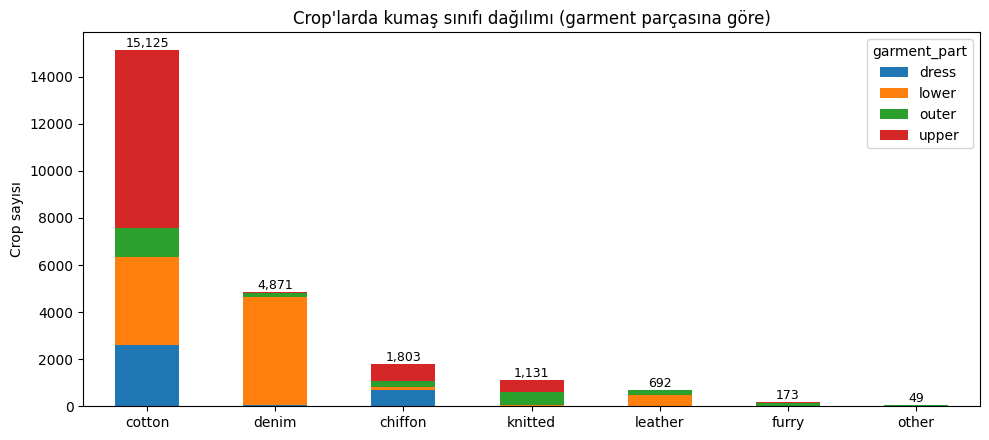

In [15]:
order = manifest["fabric_label"].value_counts().index                  # en kalabalıktan en aza
table = pd.crosstab(manifest["fabric_label"], manifest["garment_part"]).loc[order]
print(table)

ax = table.plot(kind="bar", stacked=True, figsize=(10, 4.5))           # parçalar üst üste
for i, total in enumerate(table.sum(axis=1)):                           # çubukların üstüne toplam yaz
    ax.text(i, total, f"{total:,}", ha="center", va="bottom", fontsize=9)
ax.set_title("Crop'larda kumaş sınıfı dağılımı (garment parçasına göre)")
ax.set_xlabel("")
ax.set_ylabel("Crop sayısı")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "01_class_distribution.png"), dpi=150)
plt.show()

### 12.2 Her sınıftan örnek crop'lar

Her kumaş sınıfından rastgele 6 crop. Modelin neyi ayırt etmesi gerektiğini ve sınıfların görsel olarak ne kadar benzediğini gösterir.

In [16]:
classes = list(order)
n_show = 6
fig, axes = plt.subplots(len(classes), n_show, figsize=(n_show * 1.8, len(classes) * 1.9))
for r, cls in enumerate(classes):
    subset = manifest[manifest["fabric_label"] == cls]
    picks = subset.sample(min(n_show, len(subset)), random_state=0)     # sınıftan rastgele 6
    for c in range(n_show):
        ax = axes[r, c]
        ax.axis("off")
        if c < len(picks):
            path = os.path.join(CROP_DIR, picks.iloc[c]["crop_file"])
            ax.imshow(cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB))   # diskten oku, BGR -> RGB
            ax.set_title(picks.iloc[c]["garment_part"], fontsize=7)
    axes[r, 0].text(-0.15, 0.5, cls, transform=axes[r, 0].transAxes,     # satır başına sınıf adı
                    ha="right", va="center", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "02_sample_crops.png"), dpi=150)
plt.show()

*[Görsel kaldırıldı: DeepFashion-MultiModal lisansı veri seti görüntülerinin yayınlanmasına izin vermiyor.]*

### 12.3 Kıyafet alanı dağılımı (crop kalitesi)

`mask_pixels`: kıyafetin orijinal fotoğrafta kapladığı piksel sayısı (fotoğraf 1101×750 ≈ 826 bin piksel). Çok küçük alanlar (ceketin altından görünen şerit gibi) az bilgi taşır → eşik belirleyip eleyeceğiz. Yatay eksen logaritmik: küçük değerler de okunabilsin.

Alan yüzdelikleri (piksel):
count     23844.0
mean      56195.0
std       34161.0
min          53.0
1%         3455.0
5%        11496.0
10%       18160.0
25%       30476.0
50%       53030.0
max      709532.0
Name: mask_pixels, dtype: float64


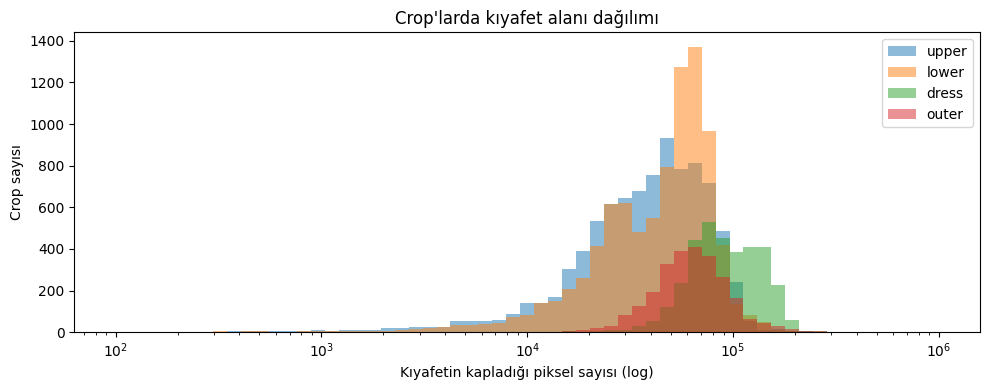

*[Görsel kaldırıldı: DeepFashion-MultiModal lisansı veri seti görüntülerinin yayınlanmasına izin vermiyor.]*

In [17]:
print("Alan yüzdelikleri (piksel):")
print(manifest["mask_pixels"].describe(percentiles=[.01, .05, .10, .25, .5]).round(0))

fig, ax = plt.subplots(figsize=(10, 4))
for part_name in ["upper", "lower", "dress", "outer"]:
    vals = manifest.loc[manifest["garment_part"] == part_name, "mask_pixels"]
    ax.hist(vals, bins=np.logspace(2, 6, 60), alpha=0.5, label=part_name)   # log aralıklı kutular
ax.set_xscale("log")
ax.set_xlabel("Kıyafetin kapladığı piksel sayısı (log)")
ax.set_ylabel("Crop sayısı")
ax.set_title("Crop'larda kıyafet alanı dağılımı")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "03_mask_area_hist.png"), dpi=150)
plt.show()

smallest = manifest.nsmallest(8, "mask_pixels")                         # en küçük 8 crop
fig, axes = plt.subplots(1, 8, figsize=(16, 2.6))
for ax, (_, r) in zip(axes, smallest.iterrows()):
    ax.imshow(cv2.cvtColor(cv2.imread(os.path.join(CROP_DIR, r["crop_file"])), cv2.COLOR_BGR2RGB))
    ax.set_title(f"{r['garment_part']}\n{r['mask_pixels']:,} px", fontsize=8)
    ax.axis("off")
plt.suptitle("En küçük alanlı 8 crop")
plt.tight_layout()
plt.show()

**EDA bulguları:**

1. **Sınıf dağılımı (12.1):** cotton %63, other %0,2 → ciddi dengesizlik. **Denim crop'larının %94'ü pantolon (lower)**, leather'ın çoğu lower + outer, furry'nin çoğu outer, knitted'ın çoğu outer + upper → kumaş ile kıyafet parçası güçlü şekilde ilişkili; model dokuyu değil şekli öğrenebilir (*shortcut learning*). Hata analizinde denim olmayan pantolonlar ve denim gömlekler/ceketler ayrıca incelenecek.
2. **Örnek crop'lar (12.2):**
   - cotton ↔ knitted sınırı belirsiz (cotton satırındaki gri kazak örgü gibi görünüyor) → beklenen karışıklık.
   - Beyaz şortlar ve beyaz pantolonlar da denim → renk kumaşı belirlemiyor.
   - **furry** crop'larının çoğu açık ceketlerden kalan kol parçaları; kürk dokusu sadece bir kısmında net.
   - **other** kendi içinde tutarsız (pul, simli, metalik kumaşlar) ve sadece 49 örnek.
   - Açık ceketlerde (outer) içteki giysi silindiği için crop iki kol parçasına bölünüyor.
3. **Alan dağılımı (12.3):** medyan ~53.000 piksel; crop'ların %1'i 3.455, %5'i 11.496 pikselin altında. En küçük crop'lar dokusu okunamayan ince şeritler.

**Kararlar:**
- **Nihai sınıflar (6):** cotton, denim, chiffon, knitted, leather, furry. `other` çıkarıldı (49 örnek, tutarsız). furry nadir ama tutuluyor → class weight ile desteklenecek.
- **Alan eşiği:** `mask_pixels ≥ 10.000` (≈100×100 px kıyafet alanı).

## 13. Filtre, nihai sınıflar ve train / validation / test split

In [18]:
MIN_PIXELS = 10_000
CLASSES = ["cotton", "denim", "chiffon", "knitted", "leather", "furry"]     # model sınıfları (sıra = index)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}

keep = (manifest["mask_pixels"] >= MIN_PIXELS) & manifest["fabric_label"].isin(CLASSES)
final = manifest[keep].reset_index(drop=True)                               # 0'dan yeniden numarala
final["label_idx"] = final["fabric_label"].map(CLASS_TO_IDX)                # model için sayı etiket

compare = pd.DataFrame({"önce": manifest["fabric_label"].value_counts(),
                        "sonra": final["fabric_label"].value_counts()}).fillna(0).astype(int)
compare["kayıp %"] = (100 * (1 - compare["sonra"] / compare["önce"])).round(1)
print(compare)
print("\nToplam crop:", len(manifest), "->", len(final))

               önce  sonra  kayıp %
fabric_label                       
chiffon        1803   1770      1.8
cotton        15125  14482      4.3
denim          4871   4670      4.1
furry           173    173      0.0
knitted        1131   1114      1.5
leather         692    637      7.9
other            49      0    100.0

Toplam crop: 23844 -> 22846


**Split yöntemi:** Aynı ürünün farklı fotoğrafları (`id_00000089-01`, `-02`...) birbirine çok benzer. Biri train'e, diğeri test'e düşerse model sınavda "gördüğü" bir kıyafetle karşılaşır → test başarısı yapay olarak yüksek çıkar (**data leakage**). Bu yüzden split **ürün numarası** (`item_no`, ör. `id_00000089`) seviyesinde yapılıyor: bir ürünün bütün crop'ları aynı sette. (İlk denemede kategori adı dahil `product_id` kullanıldı; 13.1'deki sıkı kontrol aynı numaranın farklı kategori adıyla 12 üründe setler arasına bölündüğünü gösterdi → gruplama sadece numaraya çevrildi.)

`StratifiedGroupKFold` iki şeyi birlikte sağlar: **group** → aynı ürün tek sette; **stratified** → her sette sınıf oranları (özellikle nadir furry/leather) benzer.
- Önce veriyi 7 parçaya bölüp 1'ini **test** (~%14) ayırıyoruz.
- Kalanı 6 parçaya bölüp 1'ini **validation** (~%14) ayırıyoruz; geri kalan **train** (~%72).
- `random_state=42` → her çalıştırmada aynı split (tekrarlanabilirlik). **Test seti model geliştirme sırasında kullanılmayacak.**

In [19]:
from sklearn.model_selection import StratifiedGroupKFold

# Grup = sadece ürün numarası (id_00000089). Kategori adı dahil edilmiyor: aynı numara
# farklı kategori adıyla da geçebiliyor (13.1'de 12 ürün bulundu) -> en sıkı gruplama.
final["item_no"] = final["image_name"].str.extract(r"(id_\d+)")[0]

sgkf = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=42)
trainval_idx, test_idx = next(sgkf.split(final, final["label_idx"], final["item_no"]))      # 1/7 test

tv = final.iloc[trainval_idx]
sgkf2 = StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=42)
_, val_rel = next(sgkf2.split(tv, tv["label_idx"], tv["item_no"]))                        # kalanın 1/6'sı val

final["split"] = "train"
final.loc[test_idx, "split"] = "test"
final.loc[tv.index[val_rel], "split"] = "val"

# Leakage kontrolü: bir ürün birden fazla sette olmamalı
ids = {s: set(final.loc[final["split"] == s, "item_no"]) for s in ["train", "val", "test"]}
print("Ortak ürün  train∩val:", len(ids["train"] & ids["val"]),
      "| train∩test:", len(ids["train"] & ids["test"]), "| val∩test:", len(ids["val"] & ids["test"]))

print("\nSet oranları:\n", final["split"].value_counts(normalize=True).round(3))
print("\nSınıf × set:\n", pd.crosstab(final["fabric_label"], final["split"]).loc[CLASSES][["train", "val", "test"]])

final.to_csv(os.path.join(PROC_DIR, "manifest_final.csv"), index=False)
print("\nKaydedildi: processed/manifest_final.csv")

Ortak ürün  train∩val: 0 | train∩test: 0 | val∩test: 0

Set oranları:
 split
train    0.718
test     0.141
val      0.140
Name: proportion, dtype: float64

Sınıf × set:
 split         train   val  test
fabric_label                   
cotton        10351  2027  2104
denim          3402   618   650
chiffon        1290   283   197
knitted         797   154   163
leather         440   105    92
furry           127    21    25

Kaydedildi: processed/manifest_final.csv


### 13.1 Leakage kontrolü (ayrıntılı)

Split'in gerçekten "aynı ürün tek sette" kuralına uyduğunu üç yoldan doğruluyoruz:
1. **Kaç ürünün birden fazla fotoğrafı var?** (sorunun gerçekten var olduğunu göster)
2. **Daha sıkı ID kontrolü:** `product_id` kategori adını da içeriyor (`WOMEN-Dresses-id_00000123`). Aynı ürün numarası farklı bir kategori adıyla da listelenmiş olabilir → sadece sayısal kısma (`id_00000123`) göre de setler arası çakışma var mı?
3. **Somut örnek:** çok fotoğraflı bir ürünün bütün crop'ları ve düştükleri set.

In [20]:
photos_per_product = final.groupby("product_id")["image_name"].nunique()      # ürün başına farklı fotoğraf
print("Toplam ürün:", len(photos_per_product))
print("Birden fazla fotoğrafı olan ürün:", int((photos_per_product > 1).sum()),
      f"({(photos_per_product > 1).mean():.0%})")
print("Ürün başına fotoğraf dağılımı:\n", photos_per_product.value_counts().sort_index())

# Her ürün kaç farklı sete düşmüş? Hepsi 1 olmalı
sets_per_product = final.groupby("product_id")["split"].nunique()
print("\nBirden fazla sete düşen ürün (product_id):", int((sets_per_product > 1).sum()))

# Daha sıkı: sadece sayısal ürün numarasına göre
final["item_no"] = final["image_name"].str.extract(r"(id_\d+)")[0]
sets_per_item = final.groupby("item_no")["split"].nunique()
print("Birden fazla sete düşen ürün (sadece id numarası):", int((sets_per_item > 1).sum()))

# Aynı fotoğrafın crop'ları (ör. upper + lower) aynı sette mi?
print("Birden fazla sete düşen fotoğraf:", int((final.groupby("image_name")["split"].nunique() > 1).sum()))

# Somut örnek: en çok fotoğrafı olan ürün
example_id = photos_per_product.idxmax()
print(f"\nÖrnek ürün: {example_id}")
print(final.loc[final["product_id"] == example_id, ["image_name", "garment_part", "fabric_label", "split"]].to_string(index=False))

Toplam ürün: 6880
Birden fazla fotoğrafı olan ürün: 2652 (39%)
Ürün başına fotoğraf dağılımı:
 image_name
1     4228
2     1356
3      724
4      264
5       92
6       72
7       46
8       26
9       28
10      11
11       4
12       6
13       1
14       3
15       2
16       3
17       3
18       2
19       1
20       1
21       2
24       1
30       1
31       1
32       1
35       1
Name: count, dtype: int64

Birden fazla sete düşen ürün (product_id): 0
Birden fazla sete düşen ürün (sadece id numarası): 0
Birden fazla sete düşen fotoğraf: 0

Örnek ürün: <veri-seti-dosyası>
                                      image_name garment_part fabric_label split
      <veri-seti-dosyası>        upper       cotton  test
      <veri-seti-dosyası>        lower        denim  test
      <veri-seti-dosyası>        upper       cotton  test
      <veri-seti-dosyası>        lower        denim  test
      <veri-seti-dosyası>        upper       cotton  test
      <veri-seti-dosyası>        lower     

**Bulgu (13 + 13.1):**
- Filtre sonrası **22.846 crop** (other çıkarıldı; en çok kayıp leather %7,9 — küçük deri parçalar).
- 6.880 ürünün **2.652'sinin (%39) birden fazla fotoğrafı var** (bir tişörtün 35 fotoğrafı bile var) → ürün bazlı split şart.
- İlk split kategori adını içeren `product_id` ile yapıldı; sıkı kontrol aynı ürün numarasının farklı kategori adlarıyla **12 üründe** iki sete bölündüğünü gösterdi. Gruplama yalnızca ürün numarasına (`item_no`) çevrildi → **setler arası ortak ürün: 0 / 0 / 0**, ortak fotoğraf: 0.
- Nihai split: train %71,8 · val %14,0 · test %14,1. Nadir sınıflar her sette var (furry: 127 / 21 / 25, leather: 440 / 105 / 92).

Not: furry validation'da 21, test'te 25 örnek → bu sınıfın metrikleri istatistiksel olarak oynak olacak (raporda belirtilecek).

## 14. Custom CNN (baseline)

**Amaç:** En yüksek başarıyı almak değil; sıfırdan eğitilen basit bir CNN ile transfer learning'i (EfficientNetV2B0) **aynı veri üzerinde** karşılaştırmak.

**Temel kavramlar:**
- **CNN (Convolutional Neural Network):** Görüntü üzerinde küçük filtreler (ör. 3×3) kaydırarak kenar, doku, desen gibi örüntüleri öğrenen ağ. İlk katmanlar basit (kenar), sonrakiler karmaşık (dokuma, örgü) örüntüler öğrenir.
- **Conv2D:** filtre katmanı · **ReLU:** negatifleri 0 yapan aktivasyon · **MaxPooling:** boyutu yarıya indirir, en güçlü sinyali tutar.
- **GlobalAveragePooling:** her filtre haritasını tek sayıya indirir → az parametre, daha az ezber.
- **Dropout:** eğitimde nöronların bir kısmını rastgele kapatır → ezberi (**overfitting**) azaltır.
- **Softmax:** çıktıyı 6 sınıf için toplamı 1 olan olasılıklara çevirir (en yüksek = tahmin, değeri = **confidence**).
- **Loss (SparseCategoricalCrossentropy):** tahmin ile gerçek etiket arasındaki hata; etiketler tek sayı (0-5) olduğu için "Sparse".
- **Optimizer (Adam):** loss'u azaltacak yönde ağırlıkları günceller; **learning rate** adım büyüklüğü.
- **Epoch:** train setinin tamamının bir kez görülmesi · **Batch:** tek seferde işlenen örnek sayısı (32).
- **Class weight:** nadir sınıfın hatası daha ağır cezalandırılır → model her şeye "cotton" demeyi öğrenmesin.
- **EarlyStopping:** validation loss 5 epoch iyileşmezse durur, en iyi ağırlıklara döner · **ModelCheckpoint:** en iyi modeli kaydeder.

### 14.1 Veri hattı (tf.data), class weight ve augmentation

- `make_ds`: manifest'teki dosya yollarından (görüntü, etiket) çiftleri üretir; train'de karıştırır (`shuffle`), batch'ler, sonraki batch'i önceden hazırlar (`prefetch`). Pikseller 0-255 bırakılıyor; ölçekleme modelin içinde.
- **Augmentation:** her epoch'ta görüntüleri hafifçe değiştirerek modeli gerçek dünyadaki farklılıklara (açı, ışık, konum) dayanıklı yapar. Plana uygun: yatay çevirme, küçük döndürme (±~11°), hafif zoom/kaydırma, hafif parlaklık/kontrast. **Dikey çevirme ve güçlü renk değişimi yok.** Boşluklar beyazla doldurulur. Augmentation katmanları **sadece eğitimde** çalışır.

In [21]:
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score

MODELS_DIR = os.path.join(PROJECT_DIR, "models")
IMG_SIZE, BATCH = 224, 32
AUTOTUNE = tf.data.AUTOTUNE
keras.utils.set_random_seed(42)                                   # tekrarlanabilirlik

train_df = final[final["split"] == "train"].reset_index(drop=True)
val_df   = final[final["split"] == "val"].reset_index(drop=True)
test_df  = final[final["split"] == "test"].reset_index(drop=True)

def load_image(path, label):
    img = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)    # dosya -> 224x224x3 (0-255)
    return tf.cast(img, tf.float32), label

def make_ds(df, training):
    paths = [os.path.join(CROP_DIR, f) for f in df["crop_file"]]
    ds = tf.data.Dataset.from_tensor_slices((paths, df["label_idx"].values))
    if training:
        ds = ds.shuffle(len(df), seed=42)                          # her epoch farklı sıra
    return ds.map(load_image, num_parallel_calls=AUTOTUNE).batch(BATCH).prefetch(AUTOTUNE)

train_ds = make_ds(train_df, training=True)
val_ds   = make_ds(val_df, training=False)                        # karıştırma yok: sıra manifest ile aynı
test_ds  = make_ds(test_df, training=False)

weights = compute_class_weight("balanced", classes=np.arange(len(CLASSES)), y=train_df["label_idx"])
class_weights = dict(enumerate(weights))                         # {0: ağırlık, 1: ağırlık, ...}
print("Class weights:", {CLASSES[k]: round(float(v), 2) for k, v in class_weights.items()})

augment = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.03, fill_mode="constant", fill_value=255.0),       # ±~11 derece
    layers.RandomZoom(0.1, fill_mode="constant", fill_value=255.0),
    layers.RandomTranslation(0.05, 0.05, fill_mode="constant", fill_value=255.0),
    layers.RandomBrightness(0.1, value_range=(0, 255)),
    layers.RandomContrast(0.1),
], name="augmentation")

imgs, labels = next(iter(train_ds))                               # augmentation örneği (rapor için)
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for c in range(6):
    axes[0, c].imshow(imgs[c].numpy().astype("uint8"))
    axes[0, c].set_title(CLASSES[int(labels[c])], fontsize=9)
    aug = augment(imgs[c:c + 1], training=True)[0].numpy()
    axes[1, c].imshow(np.clip(aug, 0, 255).astype("uint8"))
    axes[1, c].set_title("augmented", fontsize=9)
for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "04_augmentation.png"), dpi=150)
plt.show()

Class weights: {'cotton': 0.26, 'denim': 0.8, 'chiffon': 2.12, 'knitted': 3.43, 'leather': 6.21, 'furry': 21.53}


*[Görsel kaldırıldı: DeepFashion-MultiModal lisansı veri seti görüntülerinin yayınlanmasına izin vermiyor.]*

### 14.2 Model mimarisi

`Input → Augmentation → Rescaling(1/255) → [Conv2D(32) → ReLU → MaxPool] → [Conv2D(64) → ReLU → MaxPool] → [Conv2D(128) → ReLU → MaxPool] → GlobalAveragePooling → Dropout(0.3) → Dense(6, softmax)`

Rescaling: 0-255 pikselleri 0-1 aralığına getirir (sinir ağları küçük sayılarla daha kararlı öğrenir).

In [22]:
def build_cnn():
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = augment(inputs)                                           # sadece eğitimde aktif
    x = layers.Rescaling(1.0 / 255)(x)                            # 0-255 -> 0-1
    for filters in [32, 64, 128]:                                 # 3 konvolüsyon bloğu
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.MaxPooling2D()(x)                              # boyut yarıya: 224->112->56->28
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(len(CLASSES), activation="softmax")(x)
    return keras.Model(inputs, outputs, name="custom_cnn")

cnn = build_cnn()
cnn.compile(optimizer=keras.optimizers.Adam(1e-3),
            loss=keras.losses.SparseCategoricalCrossentropy(),
            metrics=["accuracy"])
cnn.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,022 (367.27 KB)

 Trainable params: 94,022 (367.27 KB)

 Non-trainable params: 0 (0.00 B)

### 14.3 Eğitim

En fazla 40 epoch; EarlyStopping validation loss'a bakar (patience 8). Model ve eğitim geçmişi Drive'daki `models/` klasörüne kaydedilir; notebook tekrar çalıştırılırsa yeniden eğitilmez, kayıttan yüklenir.

*İlk deneme (v1, patience 5, 25 epoch):* 11. epoch'ta durdu; train ve validation eğrileri hâlâ iyileşiyordu (**underfitting**, model öğrenmeyi bitirmemişti). Validation: accuracy 0,289, Macro F1 0,261. Baseline'a adil şans vermek için v2'de patience 8 ve en fazla 40 epoch.

In [23]:
CNN_PATH = os.path.join(MODELS_DIR, "cnn_baseline_v2.keras")
CNN_HIST = os.path.join(MODELS_DIR, "cnn_baseline_v2_history.csv")

if os.path.exists(CNN_PATH) and os.path.exists(CNN_HIST):         # daha önce eğitildiyse yükle
    cnn = keras.models.load_model(CNN_PATH)
    cnn_hist = pd.read_csv(CNN_HIST)
    print("Kayıtlı model yüklendi.")
else:
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
        keras.callbacks.ModelCheckpoint(CNN_PATH, monitor="val_loss", save_best_only=True),
    ]
    h = cnn.fit(train_ds, validation_data=val_ds, epochs=40,
                class_weight=class_weights, callbacks=callbacks)
    cnn_hist = pd.DataFrame(h.history)
    cnn_hist.to_csv(CNN_HIST, index=False)

Kayıtlı model yüklendi.


### 14.4 Eğitim eğrileri ve validation sonuçları

- **Eğriler:** train ve validation birlikte iyileşiyorsa model öğreniyor; train iyileşirken validation kötüleşiyorsa **overfitting** (ezber).
- **Validation raporu:** her sınıf için precision / recall / F1. Test seti hâlâ kullanılmıyor (final karşılaştırmada bir kez kullanılacak).
- **Precision:** "furry" dediklerinin kaçı gerçekten furry? · **Recall:** gerçek furry'lerin kaçını buldu? · **F1:** ikisinin dengeli ortalaması · **Macro F1:** sınıf F1'lerinin eşit ağırlıklı ortalaması (nadir sınıflar da eşit sayılır).

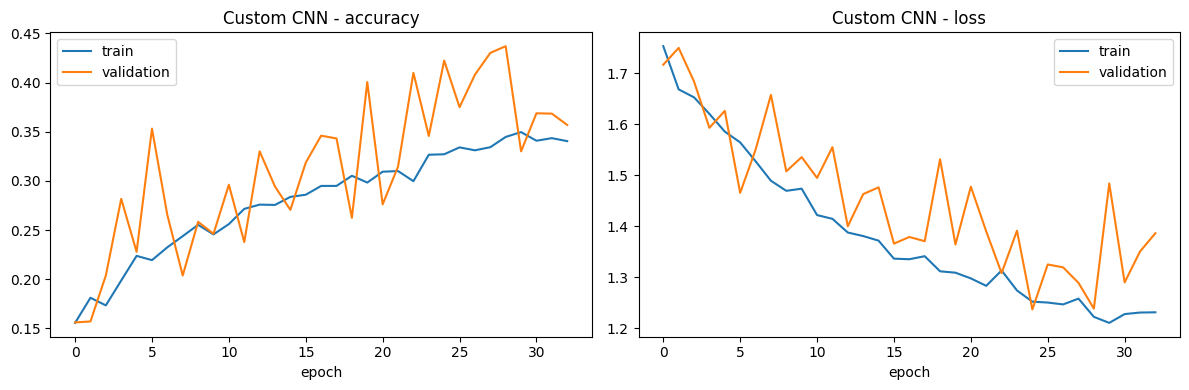

Custom CNN (validation)  accuracy=0.422  macro F1=0.365
              precision    recall  f1-score   support

      cotton      0.818     0.296     0.434      2027
       denim      0.592     0.806     0.683       618
     chiffon      0.184     0.527     0.272       283
     knitted      0.086     0.357     0.138       154
     leather      0.309     0.438     0.362       105
       furry      0.250     0.381     0.302        21

    accuracy                          0.422      3208
   macro avg      0.373     0.467     0.365      3208
weighted avg      0.663     0.422     0.450      3208



In [24]:
def plot_history(hist, title, filename):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric in zip(axes, ["accuracy", "loss"]):
        ax.plot(hist[metric], label="train")
        ax.plot(hist["val_" + metric], label="validation")
        ax.set_title(f"{title} - {metric}")
        ax.set_xlabel("epoch")
        ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, filename), dpi=150)
    plt.show()

def evaluate(model, ds, df, name):
    probs = model.predict(ds, verbose=0)                          # her crop için 6 olasılık
    pred = probs.argmax(axis=1)                                   # en yüksek olasılıklı sınıf
    true = df["label_idx"].values
    print(f"{name}  accuracy={accuracy_score(true, pred):.3f}  macro F1={f1_score(true, pred, average='macro'):.3f}")
    print(classification_report(true, pred, target_names=CLASSES, digits=3, zero_division=0))
    return probs

plot_history(cnn_hist, "Custom CNN", "05_cnn_curves.png")
cnn_val_probs = evaluate(cnn, val_ds, val_df, "Custom CNN (validation)")

## 15. EfficientNetV2B0 (transfer learning + fine-tuning)

**Transfer learning:** ImageNet'teki ~1,3 milyon fotoğrafla önceden eğitilmiş bir modelin "görme bilgisini" (kenar, doku, desen algılayan katmanları) alıp sadece son katmanı kendi problemimiz için eğitmek. Sıfırdan başlamak yerine "görmeyi zaten bilen bir uzmana kumaş dersi vermek" → daha az veriyle, daha hızlı, daha yüksek başarı.

**EfficientNetV2B0:** Google'ın verimli CNN ailesinin en küçük üyesi (~6 milyon parametre). Derinlik, genişlik ve çözünürlüğü dengeli ölçekler; 224×224 girişle çalışır. Kendi ön işlemesini (`include_preprocessing=True`) içerdiği için 0-255 piksel verebiliyoruz.

**İki aşama:**
1. **Feature extraction (backbone dondurulmuş):** EfficientNet katmanları değişmez (`trainable=False`); sadece yeni eklediğimiz sınıflandırma başı (GAP → Dropout → Dense 6) eğitilir. Learning rate 1e-3.
2. **Fine-tuning:** Backbone'un **son katmanları** açılır ve **çok küçük** learning rate (1e-5) ile birlikte eğitilir → önceden öğrenilmiş bilgi bozulmadan kumaş dokusuna uyarlanır. BatchNormalization katmanları dondurulmuş kalır (küçük batch'lerle istatistikleri bozulmasın).

Custom CNN ile **aynı** split, augmentation ve class weight kullanılıyor → karşılaştırma adil.

In [25]:
def build_effnet():
    base = keras.applications.EfficientNetV2B0(
        include_top=False, weights="imagenet",                    # ImageNet ağırlıkları, orijinal sınıflandırıcı yok
        input_shape=(IMG_SIZE, IMG_SIZE, 3), include_preprocessing=True)
    base.trainable = False                                        # Aşama 1: backbone donuk
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = augment(inputs)
    x = base(x, training=False)                                   # BatchNorm çıkarım modunda
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(len(CLASSES), activation="softmax")(x)
    return keras.Model(inputs, outputs, name="effnetv2b0"), base

eff, eff_base = build_effnet()
print("Toplam parametre:", f"{eff.count_params():,}",
      "| Eğitilebilir (aşama 1):", f"{sum(int(np.prod(w.shape)) for w in eff.trainable_weights):,}")

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Toplam parametre: 5,926,998 | Eğitilebilir (aşama 1): 7,686


### 15.1 Aşama 1: feature extraction

En fazla 15 epoch, EarlyStopping patience 5. Kayıt varsa yeniden eğitilmez.

Kayıtlı aşama 1 modeli yüklendi.


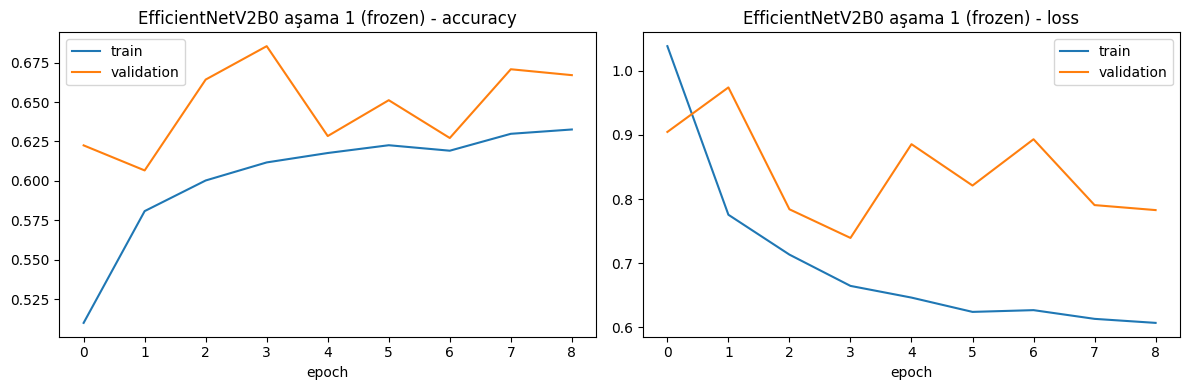

EfficientNetV2B0 frozen (validation)  accuracy=0.685  macro F1=0.625
              precision    recall  f1-score   support

      cotton      0.921     0.599     0.726      2027
       denim      0.779     0.927     0.846       618
     chiffon      0.357     0.657     0.463       283
     knitted      0.312     0.773     0.444       154
     leather      0.400     0.838     0.542       105
       furry      0.613     0.905     0.731        21

    accuracy                          0.685      3208
   macro avg      0.564     0.783     0.625      3208
weighted avg      0.796     0.685     0.706      3208



In [26]:
EFF1_PATH = os.path.join(MODELS_DIR, "effnet_stage1.keras")
EFF1_HIST = os.path.join(MODELS_DIR, "effnet_stage1_history.csv")

if os.path.exists(EFF1_PATH) and os.path.exists(EFF1_HIST):
    eff = keras.models.load_model(EFF1_PATH)
    eff_base = next(l for l in eff.layers if l.name.startswith("efficientnet"))   # EfficientNet gövdesi
    eff1_hist = pd.read_csv(EFF1_HIST)
    print("Kayıtlı aşama 1 modeli yüklendi.")
else:
    eff.compile(optimizer=keras.optimizers.Adam(1e-3),
                loss=keras.losses.SparseCategoricalCrossentropy(), metrics=["accuracy"])
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        keras.callbacks.ModelCheckpoint(EFF1_PATH, monitor="val_loss", save_best_only=True),
    ]
    h = eff.fit(train_ds, validation_data=val_ds, epochs=15,
                class_weight=class_weights, callbacks=callbacks)
    eff1_hist = pd.DataFrame(h.history)
    eff1_hist.to_csv(EFF1_HIST, index=False)

plot_history(eff1_hist, "EfficientNetV2B0 aşama 1 (frozen)", "effnet_stage1_curves.png")
eff1_val_probs = evaluate(eff, val_ds, val_df, "EfficientNetV2B0 frozen (validation)")

### 15.2 Aşama 2: fine-tuning

Backbone'un son 40 katmanı açılıyor (BatchNorm hariç), learning rate 1e-5. En fazla 15 epoch, patience 5.

*Not:* Bu ilk deneme ("balanced" class weight). 15.3'te seçilen **sqrt** modelinin fine-tuning'i en fazla **25 epoch** ile yapıldı (patience 5).

Kayıtlı fine-tuned model yüklendi.


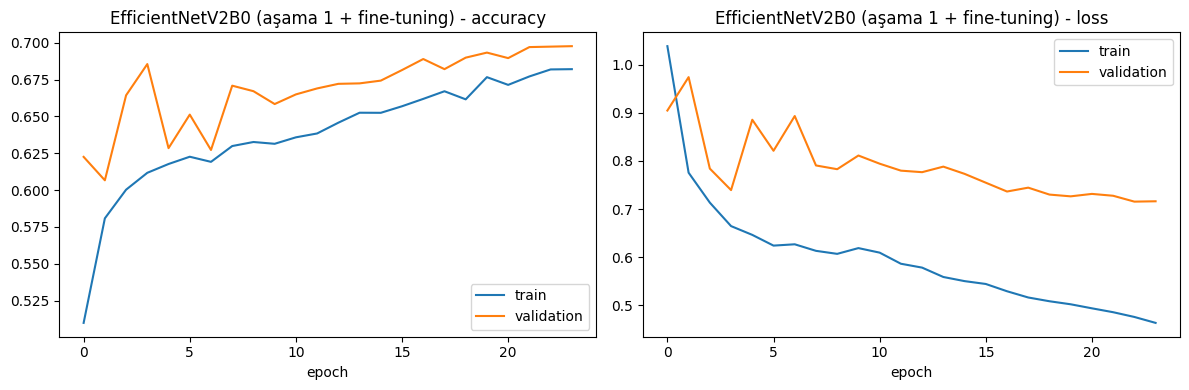

EfficientNetV2B0 fine-tuned (validation)  accuracy=0.697  macro F1=0.653
              precision    recall  f1-score   support

      cotton      0.936     0.600     0.732      2027
       denim      0.807     0.939     0.868       618
     chiffon      0.354     0.739     0.478       283
     knitted      0.316     0.779     0.449       154
     leather      0.487     0.867     0.623       105
       furry      0.645     0.952     0.769        21

    accuracy                          0.697      3208
   macro avg      0.591     0.813     0.653      3208
weighted avg      0.813     0.697     0.719      3208



In [27]:
EFF2_PATH = os.path.join(MODELS_DIR, "effnet_finetuned.keras")
EFF2_HIST = os.path.join(MODELS_DIR, "effnet_finetuned_history.csv")
UNFREEZE_LAST = 40

if os.path.exists(EFF2_PATH) and os.path.exists(EFF2_HIST):
    eff = keras.models.load_model(EFF2_PATH)
    eff2_hist = pd.read_csv(EFF2_HIST)
    print("Kayıtlı fine-tuned model yüklendi.")
else:
    eff_base.trainable = True
    for layer in eff_base.layers[:-UNFREEZE_LAST]:               # son 40 katman hariç hepsi donuk
        layer.trainable = False
    for layer in eff_base.layers:                                 # BatchNorm her zaman donuk
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
    eff.compile(optimizer=keras.optimizers.Adam(1e-5),           # çok küçük adım: bilgiyi bozma
                loss=keras.losses.SparseCategoricalCrossentropy(), metrics=["accuracy"])
    print("Eğitilebilir parametre (aşama 2):", f"{sum(int(np.prod(w.shape)) for w in eff.trainable_weights):,}")
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        keras.callbacks.ModelCheckpoint(EFF2_PATH, monitor="val_loss", save_best_only=True),
    ]
    h = eff.fit(train_ds, validation_data=val_ds, epochs=15,
                class_weight=class_weights, callbacks=callbacks)
    eff2_hist = pd.DataFrame(h.history)
    eff2_hist.to_csv(EFF2_HIST, index=False)

both = pd.concat([eff1_hist, eff2_hist], ignore_index=True)       # iki aşamayı tek grafikte
plot_history(both, "EfficientNetV2B0 (aşama 1 + fine-tuning)", "06_effnet_full_curves.png")
eff2_val_probs = evaluate(eff, val_ds, val_df, "EfficientNetV2B0 fine-tuned (validation)")

**Bulgu (validation, "balanced" class weight):**

| Model | Accuracy | Macro F1 |
|---|---|---|
| Custom CNN v1 (patience 5) | 0,289 | 0,261 |
| Custom CNN v2 (patience 8, 40 epoch) | 0,422 | 0,365 |
| EfficientNetV2B0 frozen | 0,685 | 0,625 |
| EfficientNetV2B0 fine-tuned | 0,697 | 0,653 |

- Daha uzun eğitim CNN'e yaradı (0,26 → 0,37). **Transfer learning büyük fark yarattı** (0,37 → 0,63; sadece 7.686 parametre eğitildi). Fine-tuning biraz daha iyileştirdi ve 15. epoch'ta hâlâ iyileşiyordu. Overfitting yok.
- **Zayıflık:** nadir sınıflarda recall yüksek, precision düşük (chiffon 0,35, knitted 0,32); cotton recall sadece 0,60. Sebep: "balanced" class weight'ler çok sert (furry 21,5 · cotton 0,26) → model nadir sınıfları gereğinden fazla tahmin ediyor.

### 15.3 İyileştirme denemesi: yumuşatılmış class weight

Ağırlıkların **karekökü** alınıyor (furry 21,5 → ~4,6; cotton 0,26 → ~0,51): nadir sınıflar hâlâ desteklenir ama model onları aşırı tahmin etmeye zorlanmaz. Adil karşılaştırma için **iki model de** bu ağırlıklarla yeniden eğitiliyor. EfficientNet fine-tuning'i 15. epoch'ta hâlâ iyileştiği için en fazla 25 epoch.

**Seçim kuralı:** her mimari için "balanced" ve "sqrt" versiyonlarından **validation Macro F1'i yüksek olan** seçilir (test seti karar için kullanılmaz). Eski modeller Drive'da saklanıyor.

In [28]:
soft_weights = {k: float(np.sqrt(v)) for k, v in class_weights.items()}      # karekök: daha yumuşak
HAS_GPU = len(tf.config.list_physical_devices("GPU")) > 0                    # GPU kotası yoksa eğitim atlanır
print("Yumuşatılmış class weights:", {CLASSES[k]: round(v, 2) for k, v in soft_weights.items()})

def fit_or_load(model, path, hist_path, lr, epochs, patience, weights):
    # kayıt varsa yükle, yoksa eğit + kaydet
    if os.path.exists(path) and os.path.exists(hist_path):
        print("Kayıtlı model yüklendi:", os.path.basename(path))
        return keras.models.load_model(path), pd.read_csv(hist_path)
    if not HAS_GPU:                                                           # CPU'da eğitim saatler sürer
        print("GPU yok -> eğitim atlandı:", os.path.basename(path))
        return None, None
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss=keras.losses.SparseCategoricalCrossentropy(), metrics=["accuracy"])
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True),
        keras.callbacks.ModelCheckpoint(path, monitor="val_loss", save_best_only=True),
    ]
    h = model.fit(train_ds, validation_data=val_ds, epochs=epochs, class_weight=weights, callbacks=callbacks)
    hist = pd.DataFrame(h.history)
    hist.to_csv(hist_path, index=False)
    return model, hist

# --- Custom CNN (sqrt) ---
cnn_s, cnn_s_hist = fit_or_load(build_cnn(), os.path.join(MODELS_DIR, "cnn_sqrt.keras"),
                                os.path.join(MODELS_DIR, "cnn_sqrt_history.csv"), 1e-3, 40, 8, soft_weights)

Yumuşatılmış class weights: {'cotton': 0.51, 'denim': 0.9, 'chiffon': 1.46, 'knitted': 1.85, 'leather': 2.49, 'furry': 4.64}
Kayıtlı model yüklendi: cnn_sqrt.keras


In [29]:
# --- EfficientNetV2B0 (sqrt): aşama 1 frozen ---
EFF_S1_PATH = os.path.join(MODELS_DIR, "effnet_sqrt_stage1.keras")
eff_s, eff_s1_hist, eff_s2_hist = None, None, None
if HAS_GPU or os.path.exists(EFF_S1_PATH):                          # CPU'da ve kayıt yoksa atla
    eff_s, _ = build_effnet()
    eff_s, eff_s1_hist = fit_or_load(eff_s, EFF_S1_PATH, os.path.join(MODELS_DIR, "effnet_sqrt_stage1_history.csv"),
                                     1e-3, 15, 5, soft_weights)
else:
    print("GPU yok -> EfficientNet (sqrt) eğitimi atlandı")

# --- aşama 2 fine-tuning ---
EFF_S2_PATH = os.path.join(MODELS_DIR, "effnet_sqrt_finetuned.keras")
if eff_s is not None:                                                # aşama 1 yapıldıysa (GPU varsa ya da kayıttan)
    eff_s1_val_probs = eff_s.predict(val_ds, verbose=0)              # aşama 1 sonucu (karşılaştırma için)
    base_s = next(l for l in eff_s.layers if l.name.startswith("efficientnet"))
    base_s.trainable = True
    for layer in base_s.layers[:-UNFREEZE_LAST]:
        layer.trainable = False
    for layer in base_s.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
    eff_s, eff_s2_hist = fit_or_load(eff_s, EFF_S2_PATH, os.path.join(MODELS_DIR, "effnet_sqrt_finetuned_history.csv"),
                                     1e-5, 25, 5, soft_weights)

Kayıtlı model yüklendi: effnet_sqrt_stage1.keras
Kayıtlı model yüklendi: effnet_sqrt_finetuned.keras


                              Accuracy  Macro Precision  Macro Recall  Macro F1
Custom CNN (balanced)            0.422            0.373         0.467     0.365
EffNet frozen (balanced)         0.685            0.564         0.783     0.625
EffNet fine-tuned (balanced)     0.697            0.591         0.813     0.653
Custom CNN (sqrt)                0.738            0.597         0.425     0.427
EffNet frozen (sqrt)             0.811            0.702         0.750     0.717
EffNet fine-tuned (sqrt)         0.808            0.712         0.790     0.745

Custom CNN: sqrt seçildi
EfficientNet: sqrt seçildi


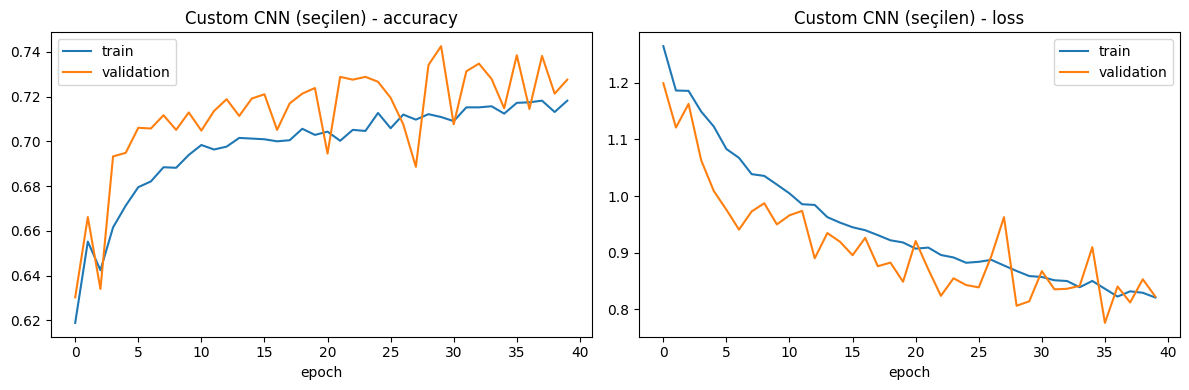

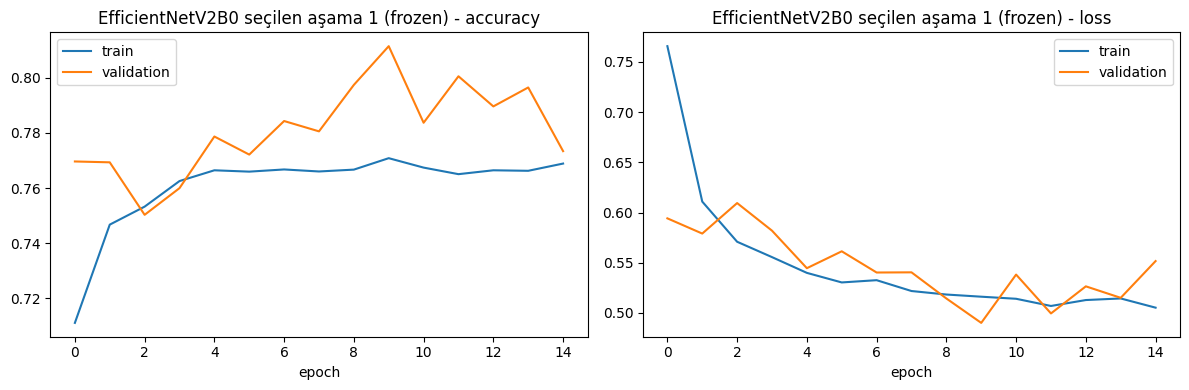

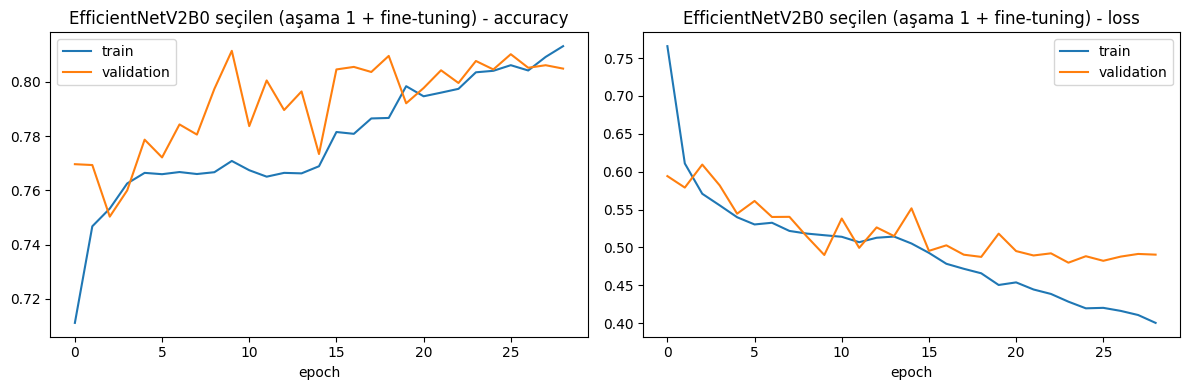

Seçilen EfficientNetV2B0 (validation)  accuracy=0.808  macro F1=0.745
              precision    recall  f1-score   support

      cotton      0.901     0.810     0.853      2027
       denim      0.839     0.937     0.885       618
     chiffon      0.495     0.572     0.531       283
     knitted      0.465     0.695     0.557       154
     leather      0.704     0.771     0.736       105
       furry      0.870     0.952     0.909        21

    accuracy                          0.808      3208
   macro avg      0.712     0.790     0.745      3208
weighted avg      0.826     0.808     0.813      3208



In [30]:
# --- Validation karşılaştırması ve seçim ---
y_val = val_df["label_idx"].values
val_candidates = {
    "Custom CNN (balanced)": cnn_val_probs,
    "EffNet frozen (balanced)": eff1_val_probs,
    "EffNet fine-tuned (balanced)": eff2_val_probs,
}
if cnn_s is not None:                                                # sqrt modeller varsa ekle
    cnn_s_val_probs = cnn_s.predict(val_ds, verbose=0)
    val_candidates["Custom CNN (sqrt)"] = cnn_s_val_probs
if eff_s is not None and eff_s2_hist is not None:
    eff_s2_val_probs = eff_s.predict(val_ds, verbose=0)
    val_candidates["EffNet frozen (sqrt)"] = eff_s1_val_probs
    val_candidates["EffNet fine-tuned (sqrt)"] = eff_s2_val_probs
val_table = pd.DataFrame({
    name: {"Accuracy": accuracy_score(y_val, pr.argmax(1)),
           "Macro Precision": precision_score(y_val, pr.argmax(1), average="macro", zero_division=0),
           "Macro Recall": recall_score(y_val, pr.argmax(1), average="macro", zero_division=0),
           "Macro F1": f1_score(y_val, pr.argmax(1), average="macro")}
    for name, pr in val_candidates.items()
}).T.round(3)
val_table.to_csv(os.path.join(PROJECT_DIR, "outputs", "validation_comparison.csv"))
print(val_table.to_string())

f1v = val_table["Macro F1"]
cnn_w, eff_w = class_weights, class_weights                  # seçilen modellerin eğitim ağırlıkları
if "Custom CNN (sqrt)" in f1v and f1v["Custom CNN (sqrt)"] > f1v["Custom CNN (balanced)"]:                  # CNN seçimi
    cnn, cnn_val_probs, cnn_hist = cnn_s, cnn_s_val_probs, cnn_s_hist
    cnn_w = soft_weights
    print("\nCustom CNN: sqrt seçildi")
else:
    print("\nCustom CNN: balanced kaldı")
if "EffNet fine-tuned (sqrt)" in f1v and f1v["EffNet fine-tuned (sqrt)"] > f1v["EffNet fine-tuned (balanced)"]:    # EfficientNet seçimi
    eff, eff2_val_probs, eff1_val_probs = eff_s, eff_s2_val_probs, eff_s1_val_probs
    eff1_hist, eff2_hist, EFF1_PATH = eff_s1_hist, eff_s2_hist, EFF_S1_PATH
    eff_w = soft_weights
    print("EfficientNet: sqrt seçildi")
else:
    print("EfficientNet: balanced kaldı")

plot_history(cnn_hist, "Custom CNN (seçilen)", "05_cnn_curves.png")
plot_history(eff1_hist, "EfficientNetV2B0 seçilen aşama 1 (frozen)", "effnet_stage1_curves.png")
plot_history(pd.concat([eff1_hist, eff2_hist], ignore_index=True),
             "EfficientNetV2B0 seçilen (aşama 1 + fine-tuning)", "06_effnet_full_curves.png")
_ = evaluate(eff, val_ds, val_df, "Seçilen EfficientNetV2B0 (validation)")

### 15.4 Karar ayarı: class weight etkisini tahmin anında dengelemek

Class weight, eğitimde nadir sınıfları öne çıkarır; yan etkisi modelin onları **gereğinden fazla** tahmin etmesidir (cotton recall düşük, chiffon/knitted precision düşük). Modeli yeniden eğitmeden bu etkiyi **tahmin anında** kısmen geri alabiliriz:

`düzeltilmiş olasılık ∝ olasılık × ağırlık^(−τ)` → sonra toplam 1 olacak şekilde normalize.

- **τ = 0:** hiçbir değişiklik (modelin kendi kararı)
- **τ = 1:** class weight'in etkisi tamamen geri alınır (nadir sınıflar artık öne çıkarılmaz)
- Aradaki değer **validation setinde Macro F1'i en yüksek yapan** τ olarak seçilir (test seti kullanılmaz). τ = 0 en iyiyse hiçbir şey değişmez.

Bu bir **post-hoc (eğitim sonrası) kalibrasyon**: model ağırlıkları değişmez, sadece son karar kuralı ayarlanır. Aşağıdaki test, hata analizi ve demo bölümleri bu ayarlı olasılıkları kullanır.

In [31]:
def adjust(probs, weights, tau):
    w = np.array([weights[k] for k in range(len(CLASSES))])
    adj = probs * np.power(w, -tau)                              # ağır sınıfların payını azalt
    return adj / adj.sum(axis=1, keepdims=True)                  # yeniden olasılığa çevir (toplam 1)

def best_tau(val_probs, weights):
    taus = np.round(np.arange(0, 1.01, 0.1), 1)
    scores = [f1_score(y_val, adjust(val_probs, weights, t).argmax(1), average="macro") for t in taus]
    return float(taus[int(np.argmax(scores))]), scores

ADJ = {}                                                          # model adı -> (ağırlıklar, tau)
tau_rows = []
for name, val_pr, w in [("Custom CNN", cnn_val_probs, cnn_w),
                        ("EfficientNetV2B0 (frozen)", eff1_val_probs, eff_w),
                        ("EfficientNetV2B0 (fine-tuned)", eff2_val_probs, eff_w)]:
    tau, scores = best_tau(val_pr, w)
    ADJ[name] = (w, tau)
    tau_rows.append({"Model": name, "tau": tau,
                     "val Macro F1 (ayarsız)": round(scores[0], 3),
                     "val Macro F1 (ayarlı)": round(max(scores), 3),
                     "val Accuracy (ayarlı)": round(accuracy_score(y_val, adjust(val_pr, w, tau).argmax(1)), 3)})
print(pd.DataFrame(tau_rows).set_index("Model").to_string())
EFF_TAU = ADJ["EfficientNetV2B0 (fine-tuned)"][1]
print("\nSeçilen EfficientNet (ayarlı) - validation:")
print(classification_report(y_val, adjust(eff2_val_probs, eff_w, EFF_TAU).argmax(1),
                            target_names=CLASSES, digits=3, zero_division=0))

                               tau  val Macro F1 (ayarsız)  val Macro F1 (ayarlı)  val Accuracy (ayarlı)
Model                                                                                                   
Custom CNN                     0.0                   0.427                  0.427                  0.738
EfficientNetV2B0 (frozen)      0.0                   0.717                  0.717                  0.811
EfficientNetV2B0 (fine-tuned)  0.3                   0.745                  0.749                  0.822

Seçilen EfficientNet (ayarlı) - validation:
              precision    recall  f1-score   support

      cotton      0.888     0.846     0.867      2027
       denim      0.845     0.935     0.888       618
     chiffon      0.532     0.523     0.528       283
     knitted      0.515     0.656     0.577       154
     leather      0.784     0.724     0.752       105
       furry      0.864     0.905     0.884        21

    accuracy                          0.822      3

**Bulgu (15.3 + 15.4, validation):**

| Model | Macro F1 ("balanced") | Macro F1 ("sqrt") |
|---|---|---|
| Custom CNN | 0,365 | **0,427** |
| EfficientNetV2B0 frozen | 0,625 | **0,717** |
| EfficientNetV2B0 fine-tuned | 0,653 | **0,745** |

- Yumuşatılmış (sqrt) ağırlıklar üç modelde de daha iyi → **iki mimari için de sqrt seçildi**. EfficientNet'te cotton recall 0,60 → 0,81; chiffon / knitted precision 0,35 / 0,32 → 0,50 / 0,47. Sert ağırlıkların "nadir sınıfları aşırı tahmin etme" sorunu büyük ölçüde çözüldü.
- **Custom CNN (sqrt)** 40 epoch'un tamamını kullandı, validation loss hâlâ iniyordu → daha uzun eğitimle biraz daha iyileşebilirdi (underfitting). Accuracy 0,738 ama Macro Recall 0,425: nadir sınıfları yakalayamıyor.
- **Eğri notu:** Keras class weight'i train loss / accuracy hesabına da uygular, validation'a uygulamaz. Bu yüzden CNN grafiğinde validation accuracy'nin train'den yüksek görünmesi hata değildir; iki eğri birebir karşılaştırılamaz.
- **EfficientNet fine-tuning** 14. epoch'ta EarlyStopping ile durdu: sona doğru train loss inmeye devam ederken validation loss ~0,49'da düzleşti → hafif overfitting başlangıcı, EarlyStopping doğru yerde durdurdu.
- **Karar ayarı (τ):** yalnızca fine-tuned modelde τ = 0,3 seçildi; kazanç küçük (Macro F1 0,745 → 0,749, accuracy 0,808 → 0,822). Diğer iki modelde τ = 0 (ayar yok). sqrt ağırlıklar dengesizliği zaten büyük ölçüde çözdüğü için post-hoc ayarın katkısı sınırlı kaldı.

## 16. Test seti: model karşılaştırması

Test seti **ilk ve tek kez** burada kullanılıyor. Üç model aynı test crop'ları üzerinde karşılaştırılıyor: Custom CNN, EfficientNetV2B0 (frozen), EfficientNetV2B0 (fine-tuned).

**Metrikler:**
- **Accuracy:** doğru tahmin oranı. Dengesiz veride yanıltıcı (her şeye "cotton" diyen model ~%63 alır).
- **Macro Precision / Recall / F1:** her sınıf için ayrı hesaplanıp **eşit ağırlıkla** ortalanır → nadir sınıflar (furry, leather) büyük sınıflar kadar sayılır. **Ana karşılaştırma metriği: Macro F1.**

Her model için 15.4'te validation setinde seçilen karar ayarı (τ) uygulanıyor.

In [32]:
y_true = test_df["label_idx"].values
models = {
    "Custom CNN": cnn,
    "EfficientNetV2B0 (frozen)": keras.models.load_model(EFF1_PATH),
    "EfficientNetV2B0 (fine-tuned)": eff,
}

rows, test_probs = [], {}
for name, model in models.items():
    probs = model.predict(test_ds, verbose=0)                     # her test crop'u için 6 olasılık
    probs = adjust(probs, *ADJ[name])                             # 15.4 karar ayarı (tau validation'dan)
    test_probs[name] = probs
    y_pred = probs.argmax(axis=1)
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro"),
    })

comparison = pd.DataFrame(rows).set_index("Model").round(3)
comparison.to_csv(os.path.join(PROJECT_DIR, "outputs", "model_comparison.csv"))
print(comparison.to_string())

best_name = comparison["Macro F1"].idxmax()                      # en iyi model: Macro F1'e göre
best_probs = test_probs[best_name]
best_pred = best_probs.argmax(axis=1)
print(f"\nEn iyi model (Macro F1): {best_name}\n")
print(classification_report(y_true, best_pred, target_names=CLASSES, digits=3, zero_division=0))

                               Accuracy  Macro Precision  Macro Recall  Macro F1
Model                                                                           
Custom CNN                        0.771            0.644         0.449     0.449
EfficientNetV2B0 (frozen)         0.827            0.704         0.748     0.718
EfficientNetV2B0 (fine-tuned)     0.831            0.740         0.736     0.730

En iyi model (Macro F1): EfficientNetV2B0 (fine-tuned)

              precision    recall  f1-score   support

      cotton      0.901     0.851     0.875      2104
       denim      0.825     0.912     0.866       650
     chiffon      0.454     0.477     0.465       197
     knitted      0.586     0.834     0.689       163
     leather      0.806     0.543     0.649        92
       furry      0.870     0.800     0.833        25

    accuracy                          0.831      3231
   macro avg      0.740     0.736     0.730      3231
weighted avg      0.840     0.831     0.832      3

### 16.1 Confusion matrix

**Nasıl okunur:** Satır = gerçek sınıf, sütun = tahmin. Köşegen (sol üstten sağ alta) doğru tahminler. Her hücrede satır içindeki oran ve parantezde sayı var → ör. "knitted" satırında "cotton" sütunu 0,30 ise gerçek knitted'ların %30'u cotton sanılmış.

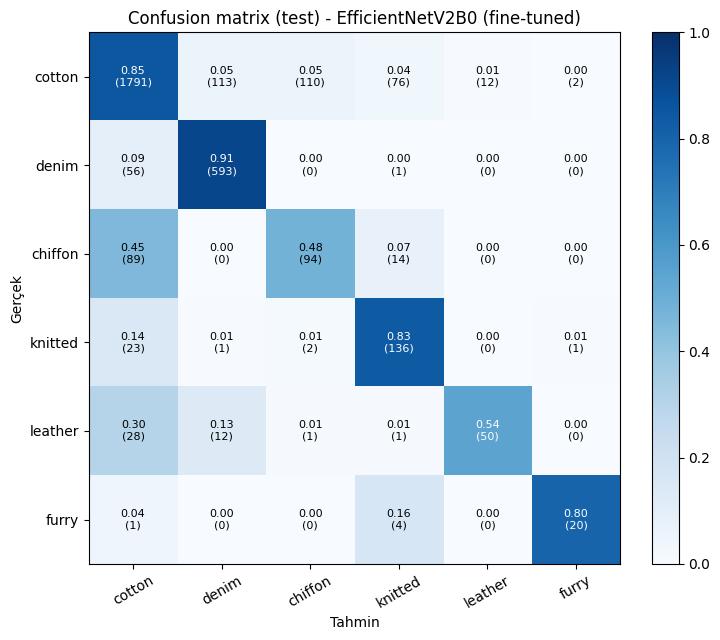

         Custom CNN  EfficientNetV2B0 (frozen)  EfficientNetV2B0 (fine-tuned)
cotton        0.846                      0.873                          0.875
denim         0.778                      0.860                          0.866
chiffon       0.153                      0.418                          0.465
knitted       0.257                      0.665                          0.689
leather       0.584                      0.667                          0.649
furry         0.077                      0.824                          0.833


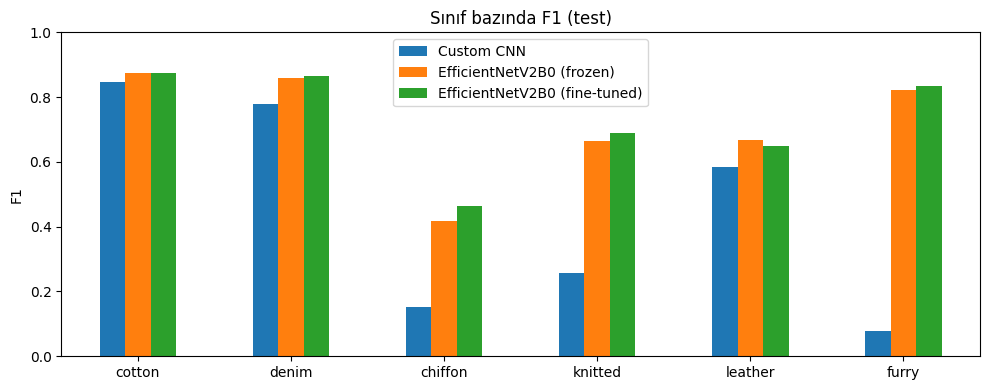

In [33]:
cm = confusion_matrix(y_true, best_pred, labels=range(len(CLASSES)))
cm_norm = cm / cm.sum(axis=1, keepdims=True)                     # her satırı kendi toplamına böl

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        ax.text(j, i, f"{cm_norm[i, j]:.2f}\n({cm[i, j]})", ha="center", va="center", fontsize=8,
                color="white" if cm_norm[i, j] > 0.5 else "black")
ax.set_xticks(range(len(CLASSES)), CLASSES, rotation=30)
ax.set_yticks(range(len(CLASSES)), CLASSES)
ax.set_xlabel("Tahmin")
ax.set_ylabel("Gerçek")
ax.set_title(f"Confusion matrix (test) - {best_name}")
fig.colorbar(im, fraction=0.046)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "07_confusion_matrix.png"), dpi=150)
plt.show()

# Sınıf bazında F1: üç model yan yana
f1_table = pd.DataFrame({name: f1_score(y_true, pr.argmax(axis=1), average=None, labels=range(len(CLASSES)))
                         for name, pr in test_probs.items()}, index=CLASSES)
print(f1_table.round(3))
ax = f1_table.plot(kind="bar", figsize=(10, 4))
ax.set_title("Sınıf bazında F1 (test)")
ax.set_ylabel("F1")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "08_f1_by_class.png"), dpi=150)
plt.show()

**Bulgu (16, test seti):**

| Model | Accuracy | Macro Precision | Macro Recall | Macro F1 |
|---|---|---|---|---|
| Custom CNN | 0,771 | 0,644 | 0,449 | 0,449 |
| EfficientNetV2B0 (frozen) | 0,827 | 0,704 | 0,748 | 0,718 |
| **EfficientNetV2B0 (fine-tuned)** | **0,831** | **0,740** | **0,736** | **0,730** |

- **Transfer learning büyük fark yarattı:** Macro F1 0,449 → 0,718 (+0,27). Fine-tuning'in ek katkısı küçük (+0,012).
- **Accuracy tek başına yanıltıcı:** Custom CNN'in accuracy'si 0,771 ama Macro F1'i 0,449. Büyük sınıfları (cotton, denim) iyi biliyor; furry F1 0,08, chiffon F1 0,15.
- **Validation → test tutarlı:** en iyi modelin Macro F1'i validation'da 0,749, testte 0,730 → aşırı uyum (overfitting) yok. Leather recall validation'da 0,72 iken testte 0,54 (92 örnek), furry'de sadece 25 test örneği var → bu iki sınıfın skorları oynak.
- **Confusion matrix:**
  - **chiffon'ların %45'i cotton sanılıyor** (en zayıf sınıf, F1 0,47). İkisi de düz yüzeyli; ince kumaşın dokusu 224×224 crop'ta çoğu zaman görünmüyor.
  - **leather'ın %30'u cotton, %13'ü denim sanılıyor:** koyu, düz yüzeyli pantolonlar birbirine benziyor.
  - **knitted:** recall yüksek (0,83) ama precision 0,59 → bazı cotton kazak/sweatshirt'ler knitted sanılıyor.
  - **denim %91, cotton %85 doğru.**

## 17. Hata analizi

1. **Shortcut kontrolü:** EDA'da denim crop'larının %94'ünün pantolon olduğunu görmüştük. Model dokuyu mu, şekli mi öğrendi?
   - Denim olmayan pantolon/eteklerin kaçına "denim" dendi? (yüksekse → "pantolon = denim" kestirmesi)
   - Pantolon olmayan denimler (ceket, gömlek) ne kadar doğru bilindi?
2. **Confidence (güven) analizi:** softmax'taki en yüksek olasılık. Doğru tahminlerde yüksek, yanlışlarda düşük olmalı. Kural motorunda "emin değilsem kullanıcıya sor" eşiği buradan seçiliyor — **eşik validation setiyle seçilir** (test seti karar vermek için kullanılmaz).
3. **Hata galerisi:** 12 yanlış tahmin (6 tanesi modelin en emin olduğu hatalar, 6 tanesi rastgele).

In [34]:
test_results = test_df.copy()
test_results["pred_label"] = [CLASSES[i] for i in best_pred]
test_results["confidence"] = best_probs.max(axis=1)
test_results["correct"] = test_results["pred_label"] == test_results["fabric_label"]

print("Parçaya göre accuracy (test):")
print(test_results.groupby("garment_part")["correct"].agg(["mean", "size"]).round(3))

lower_not_denim = test_results[(test_results["garment_part"] == "lower") & (test_results["fabric_label"] != "denim")]
denim_not_lower = test_results[(test_results["fabric_label"] == "denim") & (test_results["garment_part"] != "lower")]
print(f"\nDenim OLMAYAN alt giysilere 'denim' deme oranı: {(lower_not_denim['pred_label'] == 'denim').mean():.3f}"
      f"  (n={len(lower_not_denim)})")
print(f"Alt giysi OLMAYAN denimleri doğru bilme oranı: {denim_not_lower['correct'].mean():.3f}"
      f"  (n={len(denim_not_lower)})")
denim_lower = test_results[(test_results["fabric_label"] == "denim") & (test_results["garment_part"] == "lower")]
print(f"Alt giysi olan denimleri doğru bilme oranı:    {denim_lower['correct'].mean():.3f}  (n={len(denim_lower)})")

Parçaya göre accuracy (test):
               mean  size
garment_part             
dress         0.803   427
lower         0.831  1246
outer         0.712   358
upper         0.876  1200

Denim OLMAYAN alt giysilere 'denim' deme oranı: 0.181  (n=635)
Alt giysi OLMAYAN denimleri doğru bilme oranı: 0.615  (n=39)
Alt giysi olan denimleri doğru bilme oranı:    0.931  (n=611)


 threshold  coverage  accuracy
      0.30     1.000     0.822
      0.35     0.999     0.822
      0.40     0.995     0.825
      0.45     0.988     0.828
      0.50     0.961     0.838
      0.55     0.909     0.854
      0.60     0.860     0.872
      0.65     0.806     0.888
      0.70     0.747     0.904
      0.75     0.683     0.915
      0.80     0.616     0.927
      0.85     0.549     0.941
      0.90     0.463     0.958
      0.95     0.336     0.979

Seçilen eşik (val accuracy >= 0.85): 0.55
Test: otomatik karar 90.6% (accuracy 0.866), kullanıcıya sorulacak 9.4%


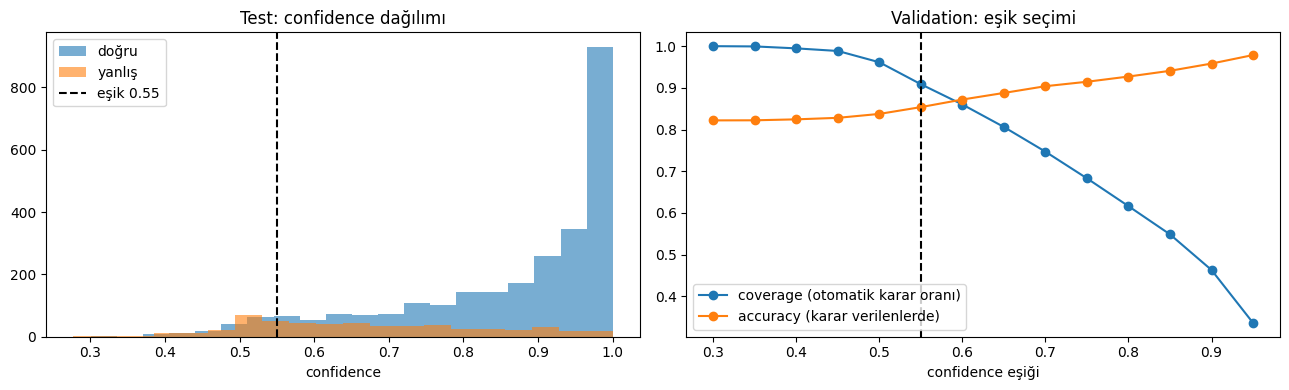

In [35]:
# Confidence eşiği: VALIDATION seti üzerinde seçiliyor
val_raw = eff2_val_probs if "fine-tuned" in best_name else (eff1_val_probs if "frozen" in best_name else cnn_val_probs)
val_best_probs = adjust(val_raw, *ADJ[best_name])                          # testle aynı karar ayarı
val_conf = val_best_probs.max(axis=1)
val_correct = val_best_probs.argmax(axis=1) == val_df["label_idx"].values

thresholds = np.round(np.arange(0.30, 0.96, 0.05), 2)
curve = pd.DataFrame({
    "threshold": thresholds,
    "coverage": [(val_conf >= t).mean() for t in thresholds],               # otomatik karar verilen oran
    "accuracy": [val_correct[val_conf >= t].mean() if (val_conf >= t).any() else np.nan for t in thresholds],
})
TARGET_ACC = 0.85
ok = curve[curve["accuracy"] >= TARGET_ACC]
CONF_THRESHOLD = float(ok["threshold"].iloc[0]) if len(ok) else 0.60      # hedefe ulaşan en düşük eşik
print(curve.round(3).to_string(index=False))
print(f"\nSeçilen eşik (val accuracy >= {TARGET_ACC}): {CONF_THRESHOLD}")

m = test_results["confidence"] >= CONF_THRESHOLD
print(f"Test: otomatik karar {m.mean():.1%} (accuracy {test_results.loc[m, 'correct'].mean():.3f}), "
      f"kullanıcıya sorulacak {1 - m.mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(test_results.loc[test_results["correct"], "confidence"], bins=20, alpha=0.6, label="doğru")
axes[0].hist(test_results.loc[~test_results["correct"], "confidence"], bins=20, alpha=0.6, label="yanlış")
axes[0].axvline(CONF_THRESHOLD, color="k", ls="--", label=f"eşik {CONF_THRESHOLD}")
axes[0].set_title("Test: confidence dağılımı")
axes[0].set_xlabel("confidence")
axes[0].legend()
axes[1].plot(curve["threshold"], curve["coverage"], marker="o", label="coverage (otomatik karar oranı)")
axes[1].plot(curve["threshold"], curve["accuracy"], marker="o", label="accuracy (karar verilenlerde)")
axes[1].axvline(CONF_THRESHOLD, color="k", ls="--")
axes[1].set_title("Validation: eşik seçimi")
axes[1].set_xlabel("confidence eşiği")
axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "09_confidence_threshold.png"), dpi=150)
plt.show()

In [36]:
wrong = test_results[~test_results["correct"]]
top_wrong = wrong.nlargest(6, "confidence")                                 # modelin en emin olduğu 6 hata
rest = wrong.drop(top_wrong.index)
gallery = pd.concat([top_wrong, rest.sample(min(6, len(rest)), random_state=0)]).reset_index(drop=True)   # + rastgele 6

fig, axes = plt.subplots(2, 6, figsize=(16, 6.5))
for ax in axes.flat:
    ax.axis("off")
for ax, (k, r) in zip(axes.flat, gallery.iterrows()):
    crop_img = cv2.cvtColor(cv2.imread(os.path.join(CROP_DIR, r["crop_file"])), cv2.COLOR_BGR2RGB)
    ax.imshow(crop_img)
    ax.set_title(f"#{k + 1} {r['garment_part']}\ngerçek: {r['fabric_label']}\ntahmin: {r['pred_label']} ({r['confidence']:.2f})",
                 fontsize=8)
    ax.axis("off")
plt.suptitle("Hata galerisi (üst satır: en emin olunan hatalar, alt satır: rastgele hatalar)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "10_error_gallery.png"), dpi=150)
plt.show()
print(gallery[["crop_file", "garment_part", "fabric_label", "pred_label", "confidence"]].round(2).to_string())

*[Görsel kaldırıldı: DeepFashion-MultiModal lisansı veri seti görüntülerinin yayınlanmasına izin vermiyor.]*

                                                     crop_file garment_part fabric_label pred_label  confidence
0            <veri-seti-dosyası>        lower       cotton      denim        1.00
1   <veri-seti-dosyası>        lower       cotton      denim        1.00
2            <veri-seti-dosyası>        lower       cotton      denim        1.00
3          <veri-seti-dosyası>        upper      chiffon     cotton        1.00
4          <veri-seti-dosyası>        lower       cotton      denim        0.99
5         <veri-seti-dosyası>        outer      chiffon    knitted        0.99
6        <veri-seti-dosyası>        upper       cotton    chiffon        0.57
7                <veri-seti-dosyası>        outer      knitted      furry        0.87
8                <veri-seti-dosyası>        upper       cotton    chiffon        0.59
9     <veri-seti-dosyası>        dress      chiffon     cotton        0.61
10      <veri-seti-dosyası>        upper       cotton    chiffon        0.87
11        

**Bulgu (17, hata analizi):**

**Parçaya göre doğruluk:** upper 0,876 · lower 0,831 · dress 0,803 · **outer 0,712**. Outer en zayıf: açık ceketlerde crop iki kol parçasından oluşuyor, doku bilgisi az.

**Shortcut kontrolü:**
- Denim olmayan alt giysilerin **%18,1'ine "denim"** deniyor (n = 635).
- Denim alt giysilerde doğruluk **%93,1**, alt giysi olmayan denimlerde (ceket, gömlek, elbise) **%61,5** (n = 39).
- → Model kumaş dokusunun yanında **kıyafet şeklini de kullanıyor** (kısmi shortcut). Ancak hata galerisi, "denim" hatalarının bir kısmının aslında **etiket hatası** olduğunu gösteriyor (aşağıda).

**Confidence:** Doğru tahminlerin çoğu 0,9'un üzerinde; yanlış tahminler 0,5-0,8 arasına yayılıyor ama bir kısmı 1,0'a kadar çıkıyor. Validation setinde %85 doğruluk hedefine ulaşan en düşük eşik **0,55** seçildi (başlangıçta düşünülen 0,60 yerine veriden). Testte kararların **%90,6'sı otomatik** (doğruluk **0,866**), **%9,4'ü kullanıcıya soruluyor**.

**Hata galerisi yorumları:**

| # | Parça | Gerçek → Tahmin (conf.) | Yorum |
|---|---|---|---|
| 1 | lower | cotton → denim (1,00) | Açık mavi, yırtık kot şort → görsel olarak açıkça denim; **etiket hatası** olası |
| 2 | lower | cotton → denim (1,00) | Açık mavi yırtık kot pantolon → **etiket hatası** olası |
| 3 | lower | cotton → denim (1,00) | Kot şort → **etiket hatası** olası |
| 4 | upper | chiffon → cotton (1,00) | Yazılı beyaz tişört; pamuklu tişört görünümünde → **etiket şüpheli** |
| 5 | lower | cotton → denim (0,99) | Açık mavi yırtık kot → **etiket hatası** olası |
| 6 | outer | chiffon → knitted (0,99) | Gri örgü hırka görünümünde → **etiket şüpheli** |
| 7 | upper | cotton → chiffon (0,57) | Beyaz, ince, işlemeli bluz; cotton / chiffon ayrımı görsel olarak zor |
| 8 | outer | knitted → furry (0,87) | Siyah, tüylü görünen iki kol parçası; crop'ta az doku var |
| 9 | upper | cotton → chiffon (0,59) | Krem gömlek; düz ve açık renkli yüzeyde doku ayırt edilemiyor |
| 10 | dress | chiffon → cotton (0,61) | Mavi tulum, yan poz; kumaş yüzeyi küçük ve düz görünüyor |
| 11 | upper | cotton → chiffon (0,87) | Pembe, dökümlü askılı bluz; görsel olarak chiffon'a çok benziyor |
| 12 | dress | cotton → knitted (0,67) | Pembe dantel elbise; dantel dokusu örgüye benziyor |

**Sonuç:** Modelin **en emin olduğu 6 hatanın 6'sı da** görsel olarak etiket hatası veya şüpheli etiket. Yani bu hataların bir kısmı modelin değil verinin; gerçek başarı raporlanan sayılardan biraz yüksek olabilir. Rastgele hatalar ise beklenen zorlukları gösteriyor: ince açık renkli kumaşlarda **cotton ↔ chiffon**, **dantel ↔ örgü**, iki kol parçasından oluşan **outer crop'lar**.

## 18. Renk analizi (OpenCV)

Renk grubu için model eğitilmiyor; **görüntü piksellerinden** açıklanabilir kurallarla çıkarılıyor.

- **Neden maske?** Sadece kıyafetin pikselleri kullanılıyor (arka plan, cilt, saç hesaba katılmıyor). Crop'lardaki beyaz arka plan da kullanılmıyor: yoksa beyaz kıyafet ile arka plan ayırt edilemezdi → renk **orijinal fotoğraf + maske** ile ölçülüyor.
- **Neden HSV?** RGB'de "açıklık" ve "renklilik" üç kanala dağılmış durumda. HSV bunları ayırıyor:
  - **H (Hue):** renk tonu (kırmızı, mavi...)
  - **S (Saturation):** doygunluk — 0'a yakınsa gri/beyaz/siyah, yüksekse canlı renk
  - **V (Value):** parlaklık — 0 siyah, 255 en parlak
- **Medyan** kullanılıyor: desenli kıyafetlerde ve gölgelerde ortalamaya göre daha dayanıklı (robust).

**Kurallar** (OpenCV'de S ve V 0-255):
| Koşul | Grup |
|---|---|
| V < 90 | dark |
| S < 35 ve V ≥ 200 | white |
| S < 35 ve 140 ≤ V < 200 | light |
| S < 35 ve V < 140 (orta gri) | dark |
| S ≥ 35 ve V ≥ 190 ve S < 80 (pastel) | light |
| diğer (canlı renk) | colored |

Eşikler evrensel değil; aşağıda örneklerle gözle kontrol ediliyor.

In [37]:
def part_codes(mask, part):
    # crop kuralıyla aynı maske bölgeleri
    if part == "upper":
        return [1]
    if part == "outer":
        return [2]
    if part == "dress":
        return [4, 21]
    return [3, 5] if np.isin(mask, [3, 5]).any() else [6]         # lower: pantolon/etek, yoksa tayt

def color_group(img, mask, codes):
    pixels = img[np.isin(mask, codes)]                            # sadece kıyafet pikselleri (N x 3, RGB)
    hsv = cv2.cvtColor(pixels.reshape(-1, 1, 3), cv2.COLOR_RGB2HSV).reshape(-1, 3)
    s, v = float(np.median(hsv[:, 1])), float(np.median(hsv[:, 2]))
    if v < 90:
        group = "dark"
    elif s < 35:
        group = "white" if v >= 200 else ("light" if v >= 140 else "dark")
    elif v >= 190 and s < 80:
        group = "light"
    else:
        group = "colored"
    return group, s, v

color_rows = []
for _, r in tqdm(test_results.iterrows(), total=len(test_results)):
    image, m = load_pair(r["image_name"])
    color_rows.append(color_group(image, m, part_codes(m, r["garment_part"])))
test_results[["color_group", "sat_median", "val_median"]] = pd.DataFrame(color_rows, index=test_results.index)
print(test_results["color_group"].value_counts())

check = pd.concat([g.sample(min(5, len(g)), random_state=1)                 # her renk grubundan 5 örnek
                   for _, g in test_results.groupby("color_group")])
fig, axes = plt.subplots(4, 5, figsize=(13, 11))
for ax, (_, r) in zip(axes.flat, check.iterrows()):
    ax.imshow(cv2.cvtColor(cv2.imread(os.path.join(CROP_DIR, r["crop_file"])), cv2.COLOR_BGR2RGB))
    ax.set_title(f"{r['color_group']}  (S={r['sat_median']:.0f}, V={r['val_median']:.0f})", fontsize=9)
    ax.axis("off")
for ax in axes.flat[len(check):]:
    ax.axis("off")
plt.suptitle("Renk grubu kontrolü: her gruptan 5 örnek")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "11_color_check.png"), dpi=150)
plt.show()

  0%|          | 0/3231 [00:00<?, ?it/s]

color_group
dark       1257
white       841
colored     734
light       399
Name: count, dtype: int64


*[Görsel kaldırıldı: DeepFashion-MultiModal lisansı veri seti görüntülerinin yayınlanmasına izin vermiyor.]*

**Bulgu (18, renk analizi):**

- Test setinde renk grubu dağılımı: dark 1.257 · white 841 · colored 734 · light 399.
- **Gözle kontrol (20 örnek, her gruptan 5):** dark ve light gruplarının hepsi makul. Sınırda / hatalı 3 örnek: bej hırka (S = 52) "colored" çıktı ama "light" olmalıydı; gri tişört (S = 42, V = 102) "colored" çıktı ama "dark" olmalıydı; siyah-beyaz bir üst "white" çıktı (beyaz pikseller çoğunlukta olduğu için medyan beyaz). → **20 örnekten ~17'si makul.**
- **Sınırlılıklar:** S = 35 doygunluk eşiği gri ve bej tonlarda sınırda kalıyor. Tek bir medyan değer çok renkli ya da desenli kıyafeti temsil etmiyor. Eşikler küçük bir örnekle gözle ayarlandı; daha büyük, elle etiketlenmiş bir renk seti ile kalibre edilmeli.

## 19. Kural motoru ve uçtan uca demo

Yıkama grubu bir modelin tahmini **değil**; kumaş (model) + renk (OpenCV) bilgisinden **açıklanabilir kurallarla** üretiliyor. Neden ayrı kural motoru? Kurallar okunabilir, değiştirilebilir ve hatalı bir öneri olduğunda nedeni izlenebilir.

| Kumaş | Renk | Yıkama grubu |
|---|---|---|
| denim | dark / colored | DARK_HEAVY |
| denim | white / light | WHITE_LIGHT_NORMAL |
| cotton | white / light | WHITE_LIGHT_NORMAL |
| cotton | dark / colored | DARK_COLOR_NORMAL |
| knitted, chiffon | (hepsi) | DELICATE |
| leather, furry | (hepsi) | LABEL_CHECK |
| confidence < eşik | — | USER_CONFIRM |

Eşik (`CONF_THRESHOLD`) 17. bölümde validation seti ile seçildi.

In [38]:
WASH_TEXT = {
    "DARK_HEAVY": "Koyu renkli ve dayanıklı ürünlerle birlikte yıkanabilir. Hassas ve açık renkli ürünlerle yıkanması önerilmez.",
    "WHITE_LIGHT_NORMAL": "Beyaz ve açık renkli ürünlerle birlikte, normal programda yıkanabilir.",
    "DARK_COLOR_NORMAL": "Koyu ve renkli ürünlerle birlikte, normal programda yıkanabilir. Beyazlarla yıkanması önerilmez.",
    "DELICATE": "Hassas ürün: hassas programda veya elde, benzer hassas ürünlerle yıkanmalı.",
    "LABEL_CHECK": "Özel bakım gerektirebilir: yıkamadan önce bakım etiketini kontrol edin.",
    "USER_CONFIRM": "Model kumaştan emin değil: lütfen kumaş türünü onaylayın.",
}

def washing_group(fabric, color):
    if fabric in ("leather", "furry"):
        return "LABEL_CHECK"
    if fabric in ("knitted", "chiffon"):
        return "DELICATE"
    if color in ("white", "light"):
        return "WHITE_LIGHT_NORMAL"
    return "DARK_HEAVY" if fabric == "denim" else "DARK_COLOR_NORMAL"

def wash_advice(image_name, part, model=eff):
    image, m = load_pair(image_name)                              # 1) fotoğraf + maske
    codes = part_codes(m, part)
    crop = make_crop(image, m, codes)                             # 2) garment crop (224x224)
    _, buf = cv2.imencode(".jpg", cv2.cvtColor(crop, cv2.COLOR_RGB2BGR))  #    eğitimdeki gibi JPEG'e kodla (crop kaydıyla aynı)
    crop = tf.io.decode_jpeg(buf.tobytes(), channels=3).numpy()          #    ve eğitimdeki gibi geri aç (load_image ile aynı)
    probs = model.predict(crop[None].astype("float32"), verbose=0)       # 3) kumaş tahmini
    probs = adjust(probs, eff_w, EFF_TAU)[0]                             #    + karar ayarı (15.4)
    fabric, conf = CLASSES[int(probs.argmax())], float(probs.max())
    color, _, _ = color_group(image, m, codes)                    # 4) renk grubu (OpenCV)
    group = washing_group(fabric, color) if conf >= CONF_THRESHOLD else "USER_CONFIRM"   # 5) kural motoru
    result = {
        "fabric": fabric,
        "fabric_confidence": round(conf, 2),
        "color_group": color,
        "washing_group": group,
        "needs_label_check": group in ("LABEL_CHECK", "USER_CONFIRM"),
    }
    return result, crop

test_results["washing_group"] = [
    washing_group(f, c) if conf >= CONF_THRESHOLD else "USER_CONFIRM"
    for f, c, conf in zip(test_results["pred_label"], test_results["color_group"], test_results["confidence"])
]
print("Test setinde yıkama grubu dağılımı:")
print(test_results["washing_group"].value_counts())

Test setinde yıkama grubu dağılımı:
washing_group
DARK_COLOR_NORMAL     1039
WHITE_LIGHT_NORMAL     963
DARK_HEAVY             505
DELICATE               351
USER_CONFIRM           304
LABEL_CHECK             69
Name: count, dtype: int64


In [39]:
import json as _json
import textwrap

demo_rows = pd.concat([g.sample(1, random_state=3)                          # her tahmin sınıfından 1 örnek
                       for _, g in test_results.groupby("pred_label")])
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, (_, r) in zip(axes.flat, demo_rows.iterrows()):
    result, crop = wash_advice(r["image_name"], r["garment_part"])
    ax.imshow(crop)
    ax.axis("off")
    ax.set_title(f"gerçek kumaş: {r['fabric_label']}", fontsize=9)
    ax.text(0.5, -0.02, _json.dumps(result, ensure_ascii=False, indent=1) + "\n\n" + textwrap.fill(WASH_TEXT[result["washing_group"]], 50),
            transform=ax.transAxes, ha="center", va="top", fontsize=7.5, family="monospace", wrap=True)
    print(r["crop_file"], "->", result)
for ax in axes.flat[len(demo_rows):]:
    ax.axis("off")
plt.suptitle("Uçtan uca demo: fotoğraf → crop → kumaş (EfficientNet) + renk (OpenCV) → yıkama grubu")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "12_demo.png"), dpi=150, bbox_inches="tight")
plt.show()

test_results.to_csv(os.path.join(PROJECT_DIR, "outputs", "test_results.csv"), index=False)

<veri-seti-dosyası> -> {'fabric': 'chiffon', 'fabric_confidence': 0.61, 'color_group': 'colored', 'washing_group': 'DELICATE', 'needs_label_check': False}
<veri-seti-dosyası> -> {'fabric': 'cotton', 'fabric_confidence': 0.98, 'color_group': 'dark', 'washing_group': 'DARK_COLOR_NORMAL', 'needs_label_check': False}
<veri-seti-dosyası> -> {'fabric': 'denim', 'fabric_confidence': 0.98, 'color_group': 'dark', 'washing_group': 'DARK_HEAVY', 'needs_label_check': False}
<veri-seti-dosyası> -> {'fabric': 'furry', 'fabric_confidence': 0.99, 'color_group': 'dark', 'washing_group': 'LABEL_CHECK', 'needs_label_check': True}
<veri-seti-dosyası> -> {'fabric': 'knitted', 'fabric_confidence': 0.77, 'color_group': 'white', 'washing_group': 'DELICATE', 'needs_label_check': False}
<veri-seti-dosyası> -> {'fabric': 'leather', 'fabric_confidence': 0.51, 'color_group': 'dark', 'washing_group': 'USER_CONFIRM', 'needs_label_check': True}


*[Görsel kaldırıldı: DeepFashion-MultiModal lisansı veri seti görüntülerinin yayınlanmasına izin vermiyor.]*

**Bulgu (19, kural motoru ve demo):**

- Test setinde yıkama grubu dağılımı: DARK_COLOR_NORMAL 1.039 · WHITE_LIGHT_NORMAL 963 · DARK_HEAVY 505 · DELICATE 351 · **USER_CONFIRM 304 (%9,4)** · LABEL_CHECK 69.
- **Demo (6 örnek):** 5'inde kumaş doğru. Cotton bir üst (iki kol parçası) chiffon sanıldı (0,61) → DELICATE. Bu güvenli yönde bir hata: hassas programda yıkamak kıyafete zarar vermez. Leather pantolonda confidence 0,51 → **USER_CONFIRM**: sistem emin olmadığında kesin karar vermiyor.
- **Öğrenilen ders:** Demo ilk sürümde crop'u JPEG'e çevirmeden modele veriyordu ve leather örneğinin tahmini "denim"e dönüyordu. Eğitimde kullanılan ön işleme ile tahmin anındaki ön işleme **aynı** olmalı. Düzeltildi: demo crop'u artık eğitimdeki gibi JPEG'e kaydedilip tekrar okunuyor.

## 20. Sonuç

**Araştırma sorusu:** *Bir kıyafet görüntüsünden kumaş ve renk bilgisi otomatik çıkarılıp açıklanabilir kurallarla anlamlı bir yıkama grubuna dönüştürülebilir mi?* → **Büyük ölçüde evet**, bazı sınırlılıklarla.

**Kumaş sınıflandırması (projenin merkezi):**
- En iyi model **EfficientNetV2B0 (fine-tuned, sqrt class weight, τ = 0,3)**: test setinde **accuracy 0,831, Macro F1 0,730** (6 sınıf, ciddi dengesizlik).
- Sıfırdan eğitilen Custom CNN: Macro F1 0,449 → **transfer learning +0,28** Macro F1 kazandırdı.
- Sonucu en çok etkileyen kararlar: **ürün numarası bazlı split** (setler arası ortak ürün 0, leakage yok), **yumuşatılmış class weight** (validation Macro F1 +0,09), **transfer learning**.
- Güçlü sınıflar: cotton (F1 0,88), denim (0,87), furry (0,83). Zayıf: **chiffon (0,47)**, çoğunlukla cotton ile karışıyor.

**Karar sistemi:**
- 0,55 confidence eşiği ile kararların %90,6'sı otomatik ve %86,6 doğru; kalan %9,4 için kullanıcıya soruluyor.
- Renk grubu (OpenCV, HSV medyanı) gözle kontrol edilen 20 örneğin ~17'sinde makul.
- Kural motoru kumaş + renkten açıklanabilir bir yıkama grubu üretiyor.

**Zayıf yönler:**
- Kumaş ile kıyafet parçası arasında güçlü bağ var: denim olmayan alt giysilerin %18'ine "denim" deniyor (shortcut).
- Veri setinde etiket gürültüsü var: en emin hataların hepsi görsel olarak şüpheli etiket.
- furry (25) ve leather (92) test örneği az → bu sınıfların metrikleri oynak.
- Görüntüler stüdyo fotoğrafı; gerçek ev fotoğraflarında performans düşebilir.
- Renk eşikleri gri, bej ve çok renkli kıyafetlerde sınırda.
- Model kapalı küme (closed-set): yalnızca 6 kumaş sınıfını bildiği için kıyafet olmayan görüntüleri reddedemez, en yakın sınıfı tahmin eder. Softmax güveni sadece bu 6 sınıf arasında göreceli olduğundan böyle girdilerde bile yüksek olabilir (ör. bir duvar fotoğrafı %93 güvenle cotton tahmin edildi); confidence eşiği bunu yakalayamaz.

**Geliştirme önerileri:**
- Şekil bilgisini azaltmak için doku odaklı yakın plan crop'lar.
- Nadir sınıflar (furry, leather, chiffon) için ek veri.
- Şüpheli etiketlerin temizlenmesi.
- Gerçek kullanıcı fotoğraflarıyla test.
- Çok renkli kıyafetler için baskın renklerin ayrı ayrı çıkarılması (ör. K-Means).
- Renk eşiklerinin elle etiketlenmiş daha büyük bir setle kalibrasyonu.
- Kıyafet olmayan görüntüleri ayıklamak için sınıflandırma öncesi bir ön kontrol (out-of-distribution tespiti).

Aşağıdaki hücre raporda kullanılan bütün sayıları tek yerde yazdırır.

In [40]:
print("=" * 70)
print("PROJE ÖZETİ (rapor için)")
print("=" * 70)
print(f"Veri: {len(final):,} crop | train {len(train_df):,} · val {len(val_df):,} · test {len(test_df):,} | sınıflar: {CLASSES}")
print(f"Seçilen class weight: CNN = {'sqrt' if cnn_w is soft_weights else 'balanced'}, "
      f"EfficientNet = {'sqrt' if eff_w is soft_weights else 'balanced'}")
print(f"Karar ayarı (tau): { {k: v[1] for k, v in ADJ.items()} }")
print(f"Epoch sayıları: CNN {len(cnn_hist)}, EffNet aşama 1 {len(eff1_hist)}, fine-tuning {len(eff2_hist)}")
print("\nValidation karşılaştırması:\n", val_table.to_string())
print("\nTEST karşılaştırması:\n", comparison.to_string())
print(f"\nEn iyi model: {best_name}")
print("\nSınıf bazında test F1:\n", f1_table.round(3).to_string())
off = cm_norm.copy()
np.fill_diagonal(off, 0)
pairs = sorted([(off[i, j], CLASSES[i], CLASSES[j], cm[i, j]) for i in range(len(CLASSES)) for j in range(len(CLASSES))], reverse=True)[:5]
print("\nEn çok karışan 5 çift (gerçek -> tahmin):")
for rate, a, b, n in pairs:
    print(f"  {a:8s} -> {b:8s}  {rate:.1%}  ({n} crop)")
print(f"\nShortcut: denim olmayan alt giysilere 'denim' deme oranı {(lower_not_denim['pred_label'] == 'denim').mean():.1%}; "
      f"alt giysi olmayan denimlerde doğruluk {denim_not_lower['correct'].mean():.1%} (n={len(denim_not_lower)}), "
      f"alt giysi denimlerde {denim_lower['correct'].mean():.1%}")
m = test_results["confidence"] >= CONF_THRESHOLD
print(f"Confidence eşiği {CONF_THRESHOLD}: testte %{100 * m.mean():.1f} otomatik karar "
      f"(doğruluk {test_results.loc[m, 'correct'].mean():.3f}), %{100 * (1 - m.mean()):.1f} kullanıcıya soruluyor")
print("\nRenk grubu dağılımı (test):\n", test_results["color_group"].value_counts().to_string())
print("\nYıkama grubu dağılımı (test):\n", test_results["washing_group"].value_counts().to_string())

PROJE ÖZETİ (rapor için)
Veri: 22,846 crop | train 16,407 · val 3,208 · test 3,231 | sınıflar: ['cotton', 'denim', 'chiffon', 'knitted', 'leather', 'furry']
Seçilen class weight: CNN = sqrt, EfficientNet = sqrt
Karar ayarı (tau): {'Custom CNN': 0.0, 'EfficientNetV2B0 (frozen)': 0.0, 'EfficientNetV2B0 (fine-tuned)': 0.3}
Epoch sayıları: CNN 40, EffNet aşama 1 15, fine-tuning 14

Validation karşılaştırması:
                               Accuracy  Macro Precision  Macro Recall  Macro F1
Custom CNN (balanced)            0.422            0.373         0.467     0.365
EffNet frozen (balanced)         0.685            0.564         0.783     0.625
EffNet fine-tuned (balanced)     0.697            0.591         0.813     0.653
Custom CNN (sqrt)                0.738            0.597         0.425     0.427
EffNet frozen (sqrt)             0.811            0.702         0.750     0.717
EffNet fine-tuned (sqrt)         0.808            0.712         0.790     0.745

TEST karşılaştırması:
       

## 21. Kendi fotoğrafınla dene (inference)

**Inference:** eğitilmiş modeli, eğitimde hiç görmediği yeni bir görüntü üzerinde kullanmak (tahmin yapmak).

**Sorun:** Dataset'te her fotoğrafın hazır bir parsing maskesi vardı; kendi fotoğrafında maske yok. Bu yüzden kıyafeti arka plandan **OpenCV GrabCut** ile ayırıyoruz:
- Fotoğrafın kenarlarından %5 içerideki bir dikdörtgen veriliyor: "kıyafet bu dikdörtgenin içinde, dışı kesin arka plan".
- GrabCut renk dağılımlarını öğrenerek her pikseli "ön plan" (kıyafet) ya da "arka plan" olarak işaretliyor.
- Sonrası eğitimle **aynı**: maske → crop (beyaz arka plan, kare, 224×224) → JPEG kaydet/oku → EfficientNet + karar ayarı → renk (HSV) → kural motoru.

**Nasıl kullanılır:**
1. Fotoğrafını Drive'da `MyDrive/WashMom_Vision/my_photos/` klasörüne yükle (**.jpg veya .png**; iPhone'un HEIC formatı okunmaz).
2. Aşağıdaki son hücrede `PHOTO_PATH` içindeki dosya adını değiştir ve çalıştır.
3. **Run All gerekmez:** ilk hücre (bağımsız hazırlık) modeli Drive'dan yükler ve gereken fonksiyonları tanımlar. GPU gerekmez; tek fotoğrafla tahmin CPU'da da birkaç saniye sürer. `my_photos` klasörü yoksa bu hücre oluşturur.

**En iyi sonuç için:** tek kıyafet, düz ve sade bir zemin, kıyafet kareyi büyük ölçüde doldursun, iyi ışık. **Sınırlılık:** model stüdyoda, insan üzerinde çekilmiş fotoğraflarla eğitildi; yere veya askıya serilmiş kıyafetlerde başarı düşebilir. Ortadaki "maske" paneline bak: kıyafet doğru ayrılmadıysa tahmin de güvenilmez olur. Model yalnızca 6 kumaş sınıfını bilir: kıyafet olmayan bir fotoğraf (ör. duvar) yüklersen de bu sınıflardan birini, hatta yüksek güvenle tahmin eder.

In [41]:
# Bağımsız hazırlık: Run All yapmadan (CPU'da bile) sadece bu bölümü çalıştırmak için.
# Run All yapılmış bir oturumda da çalıştırmak zararsız (aynı model ve aynı fonksiyonlar).
import os, json as _json
import numpy as np, pandas as pd, cv2, matplotlib.pyplot as plt, tensorflow as tf
from tensorflow import keras
from sklearn.utils.class_weight import compute_class_weight
from google.colab import drive
if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")

PROJECT_DIR = "/content/drive/MyDrive/WashMom_Vision"
CLASSES = ["cotton", "denim", "chiffon", "knitted", "leather", "furry"]
train_labels = pd.read_csv(os.path.join(PROJECT_DIR, "processed", "manifest_final.csv")).query("split == 'train'")["label_idx"]
balanced = compute_class_weight("balanced", classes=np.arange(len(CLASSES)), y=train_labels)
eff_w = {k: float(np.sqrt(v)) for k, v in enumerate(balanced)}        # seçilen modelin sqrt ağırlıkları (15.3)
EFF_TAU, CONF_THRESHOLD = 0.3, 0.55                                   # validation ile seçilen değerler (15.4, 17)
eff = keras.models.load_model(os.path.join(PROJECT_DIR, "models", "effnet_sqrt_finetuned.keras"))
os.makedirs(os.path.join(PROJECT_DIR, "my_photos"), exist_ok=True)    # fotoğraf klasörü yoksa oluştur
print("Model yüklendi. Fotoğraf klasörü:", os.path.join(PROJECT_DIR, "my_photos"))

# --- Önceki bölümlerdeki fonksiyonların birebir kopyası (10, 15.4, 18, 19. bölümler) ---
def make_crop(img, mask, codes, pad_ratio=0.08, size=224):
    part = np.isin(mask, codes)                        # bu parçaya ait pikseller True
    if part.sum() < 50:                                # parça yok ya da birkaç piksellik gürültü
        return None
    ys, xs = np.where(part)                            # True piksellerin satır/sütun konumları
    y1, y2, x1, x2 = ys.min(), ys.max(), xs.min(), xs.max()          # bounding box
    pad_y, pad_x = int((y2 - y1) * pad_ratio), int((x2 - x1) * pad_ratio)
    y1, y2 = max(0, y1 - pad_y), min(mask.shape[0], y2 + 1 + pad_y)  # +1: dilimde bitiş hariç
    x1, x2 = max(0, x1 - pad_x), min(mask.shape[1], x2 + 1 + pad_x)  # padding, resim dışına taşmadan

    clean = img.copy()                                 # orijinali bozmamak için kopya
    clean[~part] = 255                                 # kıyafet olmayan pikseller beyaz
    crop = clean[y1:y2, x1:x2]

    h, w = crop.shape[:2]
    s = max(h, w)                                      # kare kenarı = uzun kenar
    square = np.full((s, s, 3), 255, np.uint8)         # beyaz kare tuval
    top, left = (s - h) // 2, (s - w) // 2
    square[top:top + h, left:left + w] = crop          # ortaya yapıştır
    return cv2.resize(square, (size, size), interpolation=cv2.INTER_AREA)

def adjust(probs, weights, tau):
    w = np.array([weights[k] for k in range(len(CLASSES))])
    adj = probs * np.power(w, -tau)                              # ağır sınıfların payını azalt
    return adj / adj.sum(axis=1, keepdims=True)

def color_group(img, mask, codes):
    pixels = img[np.isin(mask, codes)]                            # sadece kıyafet pikselleri (N x 3, RGB)
    hsv = cv2.cvtColor(pixels.reshape(-1, 1, 3), cv2.COLOR_RGB2HSV).reshape(-1, 3)
    s, v = float(np.median(hsv[:, 1])), float(np.median(hsv[:, 2]))
    if v < 90:
        group = "dark"
    elif s < 35:
        group = "white" if v >= 200 else ("light" if v >= 140 else "dark")
    elif v >= 190 and s < 80:
        group = "light"
    else:
        group = "colored"
    return group, s, v

WASH_TEXT = {
    "DARK_HEAVY": "Koyu renkli ve dayanıklı ürünlerle birlikte yıkanabilir. Hassas ve açık renkli ürünlerle yıkanması önerilmez.",
    "WHITE_LIGHT_NORMAL": "Beyaz ve açık renkli ürünlerle birlikte, normal programda yıkanabilir.",
    "DARK_COLOR_NORMAL": "Koyu ve renkli ürünlerle birlikte, normal programda yıkanabilir. Beyazlarla yıkanması önerilmez.",
    "DELICATE": "Hassas ürün: hassas programda veya elde, benzer hassas ürünlerle yıkanmalı.",
    "LABEL_CHECK": "Özel bakım gerektirebilir: yıkamadan önce bakım etiketini kontrol edin.",
    "USER_CONFIRM": "Model kumaştan emin değil: lütfen kumaş türünü onaylayın.",
}

def washing_group(fabric, color):
    if fabric in ("leather", "furry"):
        return "LABEL_CHECK"
    if fabric in ("knitted", "chiffon"):
        return "DELICATE"
    if color in ("white", "light"):
        return "WHITE_LIGHT_NORMAL"
    return "DARK_HEAVY" if fabric == "denim" else "DARK_COLOR_NORMAL"


Model yüklendi. Fotoğraf klasörü: /content/drive/MyDrive/WashMom_Vision/my_photos


In [42]:
def garment_mask(img):
    # GrabCut: kenardan %5 içerideki dikdörtgenin içinde kıyafeti arka plandan ayırır
    h, w = img.shape[:2]
    rect = (int(w * 0.05), int(h * 0.05), int(w * 0.90), int(h * 0.90))   # (x, y, genişlik, yükseklik)
    gc = np.zeros((h, w), np.uint8)                                      # GrabCut'ın piksel etiketleri
    bgd, fgd = np.zeros((1, 65), np.float64), np.zeros((1, 65), np.float64)   # GrabCut'ın iç modelleri
    cv2.grabCut(img, gc, rect, bgd, fgd, 5, cv2.GC_INIT_WITH_RECT)      # 5 iterasyon
    return np.isin(gc, [cv2.GC_FGD, cv2.GC_PR_FGD]).astype(np.uint8)    # 1 = kıyafet, 0 = arka plan

def try_my_photo(path):
    bgr = cv2.imread(path)
    if bgr is None:
        print("Fotoğraf okunamadı, yolu ve formatı (.jpg/.png) kontrol et:", path)
        return
    img = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    scale = 800 / max(img.shape[:2])                                     # GrabCut büyük resimde yavaş
    if scale < 1:
        img = cv2.resize(img, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
    m = garment_mask(img)
    crop = make_crop(img, m, [1])                                        # eğitimdeki crop fonksiyonu
    if crop is None:
        print("Kıyafet bulunamadı: daha sade bir zeminde, kıyafet ortada olacak şekilde dene.")
        return
    _, buf = cv2.imencode(".jpg", cv2.cvtColor(crop, cv2.COLOR_RGB2BGR))  # eğitimdeki gibi JPEG
    crop = tf.io.decode_jpeg(buf.tobytes(), channels=3).numpy()
    probs = adjust(eff.predict(crop[None].astype("float32"), verbose=0), eff_w, EFF_TAU)[0]
    fabric, conf = CLASSES[int(probs.argmax())], float(probs.max())
    color, _, _ = color_group(img, m, [1])                               # renk: sadece kıyafet pikselleri
    group = washing_group(fabric, color) if conf >= CONF_THRESHOLD else "USER_CONFIRM"
    return img, m, crop, probs, {"fabric": fabric, "fabric_confidence": round(conf, 2), "color_group": color,
                                 "washing_group": group, "needs_label_check": group in ("LABEL_CHECK", "USER_CONFIRM")}

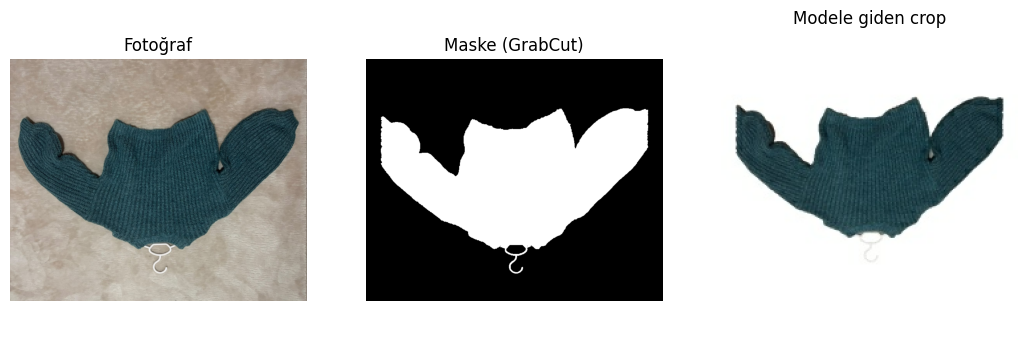

En olası kumaşlar: knitted 0.86, furry 0.10, cotton 0.04
{
 "fabric": "knitted",
 "fabric_confidence": 0.86,
 "color_group": "dark",
 "washing_group": "DELICATE",
 "needs_label_check": false
}
Hassas ürün: hassas programda veya elde, benzer hassas ürünlerle yıkanmalı.


In [46]:
PHOTO_PATH = os.path.join(PROJECT_DIR, "my_photos", "kiyafet3.jpg")      # <- kendi dosya adını yaz

out = try_my_photo(PHOTO_PATH)
if out:
    img, m, crop, probs, result = out
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
    for ax, im, title in zip(axes, [img, m, crop], ["Fotoğraf", "Maske (GrabCut)", "Modele giden crop"]):
        ax.imshow(im, cmap="gray" if im.ndim == 2 else None)
        ax.set_title(title)
        ax.axis("off")
    plt.show()
    top3 = np.argsort(probs)[::-1][:3]                                   # en olası 3 kumaş
    print("En olası kumaşlar:", ", ".join(f"{CLASSES[k]} {probs[k]:.2f}" for k in top3))
    print(_json.dumps(result, ensure_ascii=False, indent=1))                # 19. bölümdeki _json
    print(WASH_TEXT[result["washing_group"]])